# **Multi-Country African Market Analysis**  
# **Firm-Level Event Study of COVID-19 Impact**

## Overview

This notebook conducts a **multi-country firm-level event study** to examine how selected African stock markets reacted to major **COVID-19-related events**.

The analysis covers firms from:

- Ghana Stock Exchange (GSE)  
- Nigerian Exchange (NSE)  
- Egyptian Exchange (EGX)  
- Mauritius Stock Exchange (SEM)  

The **Market Model** is applied:

$$
R_{it} = \alpha_i + \beta_i R_{mt} + \epsilon_{it}
$$

to estimate **Abnormal Returns (AR)** and **Cumulative Abnormal Returns (CAR)** for each firm across different countries.

---

## Event Dates

The study focuses on the following COVID-19 events:

| Event Type | Description |
|------------|-------------|
| WHO Pandemic Declaration | Global COVID-19 shock |
| First COVID-19 Case | Country-specific shock |
| Government Lockdowns | Policy shock across countries |

These events allow comparison of **global**, **domestic**, and **policy-driven** market reactions.

---

## Event Study Design

- **Estimation Window:** 120 trading days  
- **Gap Period:** 10 trading days  
- **Event Window:** [-5, +5]

---

## Objective

To examine how firms across selected African stock markets reacted to COVID-19-related events and compare **firm-level market responses across countries**.

### Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

### data loading and preparation for Ghana

In [3]:
file_path = "../data/raw/Data Individual Stocks.xlsx"

ghana_stocks = pd.read_excel(
    file_path,
    sheet_name="GSE_STOCKS_SORTED"
)

ghana_market = pd.read_excel(
    file_path,
    sheet_name="GSE_MARKET"
)

print("Ghana stocks shape:", ghana_stocks.shape)
print("Ghana market shape:", ghana_market.shape)

Ghana stocks shape: (7231, 3)
Ghana market shape: (175, 3)


In [4]:
ghana_stocks.head(4)

,Daily Date,Share Code,Share_Return
0,20/04/2020,AADS,0.0
1,17/04/2020,AADS,0.0
2,16/04/2020,AADS,0.0
3,15/04/2020,AADS,0.0


In [5]:
ghana_market.head(4)

,Date,GSE_MRKT_RET,Unnamed: 2
0,2020-04-20,0.0086,NaN
1,2020-04-17,-0.0034,NaN
2,2020-04-16,-0.0014,NaN
3,2020-04-15,-0.0081,NaN


In [6]:
ghana_stocks.columns

Index(['Daily Date', 'Share Code', 'Share_Return'], dtype='object')

In [7]:
ghana_market.columns

Index(['Date', 'GSE_MRKT_RET', 'Unnamed: 2'], dtype='object')

In [8]:
ghana_stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7231 entries, 0 to 7230
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Daily Date    7231 non-null   object 
 1   Share Code    7231 non-null   object 
 2   Share_Return  7231 non-null   float64
dtypes: float64(1), object(2)
memory usage: 169.6+ KB


In [9]:
ghana_market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          175 non-null    datetime64[ns]
 1   GSE_MRKT_RET  175 non-null    float64       
 2   Unnamed: 2    3 non-null      object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 4.2+ KB


**Cleaning Ghana Data**

The Ghana dataset is provided in two sheets within the same workbook:

- **GSE_STOCKS_SORTED** — Firm-level stock returns  
- **GSE_MARKET** — Market index returns  

### Stock Data

The stock data is already suitable for firm-level event study analysis:

- `Daily Date` → Trading date  
- `Share Code` → Firm identifier  
- `Share_Return` → Firm return  

These variables provide the firm-level returns required for the event study.


### Market Data

The market data contains multiple columns, but only the **market return** is required for the Market Model estimation. Therefore, we retain only:

- `Date` → Trading date  
- `GSE_MRKT_RET` → Market return  

All other columns (e.g., `Unnamed: 2`) are dropped as they are not relevant for the analysis.


### Market Model

The firm-level Market Model is defined as:

$$
R_{it} = \alpha_i + \beta_i R_{mt} + \epsilon_{it}
$$

where:

- $R_{it}$ = Firm return (`Share_Return`)  
- $R_{mt}$ = Market return (`GSE_MRKT_RET`)  
- $\alpha_i$ = Firm-specific intercept  
- $\beta_i$ = Firm-specific market sensitivity  
- $\epsilon_{it}$ = Error term  

After cleaning, the stock and market data will be merged by **Date** to form the firm-level dataset for event study analysis.

In [10]:
# selecting only the useful columns
ghana_stocks = ghana_stocks[['Daily Date', 'Share Code', 'Share_Return']].copy()
ghana_market = ghana_market[['Date', 'GSE_MRKT_RET']].copy()

ghana_stocks = ghana_stocks.rename(columns={
    'Daily Date': 'Date',
    'Share Code': 'Firm',
    'Share_Return': 'Stock_Return'
})

#renaming them into standard format
ghana_market = ghana_market.rename(columns={
    'GSE_MRKT_RET': 'Market_Return'
})

ghana_stocks['Date'] = pd.to_datetime(ghana_stocks['Date'], dayfirst=True, errors='coerce')
ghana_market['Date'] = pd.to_datetime(ghana_market['Date'], dayfirst=True, errors='coerce')

ghana_stocks['Stock_Return'] = pd.to_numeric(ghana_stocks['Stock_Return'], errors='coerce')
ghana_market['Market_Return'] = pd.to_numeric(ghana_market['Market_Return'], errors='coerce')

# merging firm and market returns by date
ghana_data = pd.merge(
    ghana_stocks,
    ghana_market,
    on='Date',
    how='inner'
)

ghana_data = ghana_data.sort_values(['Firm', 'Date']).reset_index(drop=True)
ghana_data['Country'] = 'Ghana'

ghana_data.head(5)

,Date,Firm,Stock_Return,Market_Return,Country
0,2019-08-01,AADS,0.0,-0.0013,Ghana
1,2019-08-02,AADS,0.0,-0.0046,Ghana
2,2019-08-06,AADS,0.0,-0.0107,Ghana
3,2019-08-07,AADS,0.0,0.0042,Ghana
4,2019-08-08,AADS,0.0,-0.0008,Ghana


In [11]:
print("Ghana firms:", ghana_data['Firm'].nunique())
print("Earliest date:", ghana_data['Date'].min())
print("Latest date:", ghana_data['Date'].max())

Ghana firms: 42
Earliest date: 2019-08-01 00:00:00
Latest date: 2020-04-20 00:00:00


## **Event Time (t)**

instead of calendar dates, we create:
## Event Time (t) and Meaning

| Event Time (t) | Meaning                  |
|----------------|--------------------------|
| t = 0          | Event day                |
| t = -1         | 1 trading day before     |
| t = -5         | 5 trading days before    |
| t = +1         | 1 trading day after      |

---

### This is because:
- Markets don't trade on weekends  
- Markets have holidays  
- Event studies use **trading days**, not calendar days


### **Defining Ghana Events**

In [12]:
ghana_events = {
    'WHO_Declaration': pd.Timestamp('2020-03-11'),
    'First_Case': pd.Timestamp('2020-03-12'),
    'Lockdown': pd.Timestamp('2020-03-30')
}

ghana_events

{'WHO_Declaration': Timestamp('2020-03-11 00:00:00'),
 'First_Case': Timestamp('2020-03-12 00:00:00'),
 'Lockdown': Timestamp('2020-03-30 00:00:00')}

## Defining Event Study Functions

In [13]:
def create_event_time(data, event_date):
    
    event_data = []
    
    for firm, group in data.groupby('Firm'):
        
        group = group.sort_values('Date').reset_index(drop=True)
        
        if event_date not in group['Date'].values:
            continue
        
        event_index = group[group['Date'] == event_date].index[0]
        
        group['t'] = group.index - event_index
        
        event_data.append(group)
    
    return pd.concat(event_data, ignore_index=True)


def run_market_model(data, est_start=-135, est_end=-16):
    
    results = []
    
    for firm, group in data.groupby('Firm'):
        
        estimation = group[
            (group['t'] >= est_start) &
            (group['t'] <= est_end)
        ]
        
        if len(estimation) < 30:
            continue
        
        X = sm.add_constant(estimation['Market_Return'])
        y = estimation['Stock_Return']
        
        model = sm.OLS(y, X).fit()
        
        results.append({
            'Firm': firm,
            'Alpha': model.params['const'],
            'Beta': model.params['Market_Return']
        })
    
    return pd.DataFrame(results)

In [14]:
def add_market_level_car(data):
    """
    Adds:
    - AAR: Average Abnormal Return across firms for each event day t
    - Market_CAR: cumulative sum of AAR across event days
    """

    data = data.copy()

    # Average abnormal return for each event day
    data['AAR'] = data.groupby('t')['AR'].transform('mean')

    # Build one row per event day, then cumulate AAR
    market_car_map = (
        data[['t', 'AAR']]
        .drop_duplicates()
        .sort_values('t')
        .copy()
    )

    market_car_map['Market_CAR'] = market_car_map['AAR'].cumsum()

    # Merge back into the full dataset
    data = data.merge(
        market_car_map[['t', 'Market_CAR']],
        on='t',
        how='left'
    )

    return data

In [15]:
from scipy import stats

def build_event_summary(event_window_data):
    """
    Compute per-event-day statistics:
      AAR, t_stat_AAR, p_val_AAR, Sig_AAR   (cross-sectional t-test on AR)
      CAAR, t_stat_CAAR, p_val_CAAR, Sig_CAAR (cross-sectional t-test on Firm CAR)
      Avg_Firm_CAR                             (simple average of firm-level CARs)
    """
    aar_stats = (
        event_window_data
        .groupby('t')
        .agg(
            N            = ('AR',         'count'),
            AAR          = ('AR',         'mean'),
            AR_std       = ('AR',         'std'),
            CAAR         = ('Market_CAR', 'first'),
            Avg_Firm_CAR = ('CAR',        'mean'),
        )
        .reset_index()
    )

    # Cross-sectional std of firm-level CAR for CAAR t-stat
    caar_std = (
        event_window_data
        .groupby('t')['CAR']
        .std()
        .reset_index()
        .rename(columns={'CAR': 'CAR_std'})
    )
    summary = aar_stats.merge(caar_std, on='t')

    # Standard errors
    summary['AR_se']  = summary['AR_std']  / np.sqrt(summary['N'])
    summary['CAR_se'] = summary['CAR_std'] / np.sqrt(summary['N'])

    # t-statistics
    summary['t_stat_AAR']  = summary['AAR']  / summary['AR_se']
    summary['t_stat_CAAR'] = summary['CAAR'] / summary['CAR_se']

    # Two-tailed p-values using t-distribution (N-1 degrees of freedom)
    dof = summary['N'] - 1
    summary['p_val_AAR']  = 2 * (1 - stats.t.cdf(summary['t_stat_AAR'].abs(),  dof))
    summary['p_val_CAAR'] = 2 * (1 - stats.t.cdf(summary['t_stat_CAAR'].abs(), dof))

    # Significance stars: * p<0.10, ** p<0.05, *** p<0.01
    def stars(p):
        if   p < 0.01: return '***'
        elif p < 0.05: return '**'
        elif p < 0.10: return '*'
        else:          return ''

    summary['Sig_AAR']  = summary['p_val_AAR'].apply(stars)
    summary['Sig_CAAR'] = summary['p_val_CAAR'].apply(stars)

    # Drop intermediate SE/std columns
    summary = summary.drop(columns=['AR_std', 'AR_se', 'CAR_std', 'CAR_se'])

    # Round for readability
    for col in ['AAR', 'CAAR', 'Avg_Firm_CAR', 't_stat_AAR', 't_stat_CAAR',
                'p_val_AAR', 'p_val_CAAR']:
        summary[col] = summary[col].round(6)

    return summary.sort_values('t').reset_index(drop=True)


In [16]:
def fixed_window_stats(data, start_t, end_t):
    temp = data[(data['t'] >= start_t) & (data['t'] <= end_t)].copy()

    firm_car = (
        temp.groupby('Firm')['AR']
        .sum()
        .reset_index(name='CAR_window')
    )

    mean_car = firm_car['CAR_window'].mean()
    std_car = firm_car['CAR_window'].std()
    n = firm_car['CAR_window'].count()

    if std_car == 0 or pd.isna(std_car):
        t_stat = np.nan
    else:
        t_stat = mean_car / (std_car / np.sqrt(n))

    sig = 'Yes' if pd.notna(t_stat) and abs(t_stat) > 1.96 else 'No'

    return mean_car, t_stat, sig

In [17]:
def build_final_output(event_window_data):
    daily = (
        event_window_data
        .groupby(['Date', 't'])
        .agg(
            Exchange_Return=('Stock_Return', 'mean'),
            Benchmark_Return=('Expected_Return', 'mean'),
            AR=('AR', 'mean'),
            AR_std=('AR', 'std'),
            N=('AR', 'count'),
            Market_CAR=('Market_CAR', 'first'),
            Firm_CAR_std=('CAR', 'std')
        )
        .reset_index()
        .sort_values('t')
    )

    # t-stat for abnormal return
    daily['AR_se'] = daily['AR_std'] / np.sqrt(daily['N'])
    daily['T-Stat_AR'] = daily['AR'] / daily['AR_se']
    daily['Significant?(5% level)'] = np.where(
        daily['T-Stat_AR'].abs() > 1.96,
        'Yes',
        'No'
    )

    # t-stat for Market-level CAR
    daily['t-stat [-5, +5]'] = daily['Market_CAR'] / (daily['Firm_CAR_std'] / np.sqrt(daily['N']))
    daily['Sig? [-5, +5]'] = np.where(
        daily['t-stat [-5, +5]'].abs() > 1.96,
        'Yes',
        'No'
    )

    # fixed-window CAR stats
    car_m1_p1, t_m1_p1, sig_m1_p1 = fixed_window_stats(event_window_data, -1, 1)
    car_0_p1, t_0_p1, sig_0_p1 = fixed_window_stats(event_window_data, 0, 1)

    daily['CAR (-5, +5)%'] = daily['Market_CAR']
    daily['CAR (-1, +1)%'] = np.nan
    daily['t-stat [-1, +1]'] = np.nan
    daily['Sig? [-1, +1]'] = ''
    daily['CAR (0, +1)%'] = np.nan
    daily['t-stat [0, +1]'] = np.nan
    daily['Sig? [0, +1]'] = ''

    # put fixed-window values on t = 1 row
    daily.loc[daily['t'] == 1, 'CAR (-1, +1)%'] = car_m1_p1
    daily.loc[daily['t'] == 1, 't-stat [-1, +1]'] = t_m1_p1
    daily.loc[daily['t'] == 1, 'Sig? [-1, +1]'] = sig_m1_p1

    daily.loc[daily['t'] == 1, 'CAR (0, +1)%'] = car_0_p1
    daily.loc[daily['t'] == 1, 't-stat [0, +1]'] = t_0_p1
    daily.loc[daily['t'] == 1, 'Sig? [0, +1]'] = sig_0_p1

    final_output = daily.rename(columns={
        'Exchange_Return': 'Exchange_Return(%)',
        'Benchmark_Return': 'Benchmark_Return(%)',
        'AR': 'AR (%)'
    })

    final_output = final_output[
        [
            'Date', 't',
            'Exchange_Return(%)',
            'Benchmark_Return(%)',
            'AR (%)',
            'T-Stat_AR',
            'Significant?(5% level)',
            'CAR (-5, +5)%',
            't-stat [-5, +5]',
            'Sig? [-5, +5]',
            'CAR (-1, +1)%',
            't-stat [-1, +1]',
            'Sig? [-1, +1]',
            'CAR (0, +1)%',
            't-stat [0, +1]',
            'Sig? [0, +1]'
        ]
    ]

    return final_output

## Confirming the Event Time Range

In [18]:
ghana_events = {
    'WHO_Declaration': pd.Timestamp('2020-03-11'),
    'First_Case': pd.Timestamp('2020-03-12'),
    'Lockdown': pd.Timestamp('2020-03-30')
}

ghana_events

{'WHO_Declaration': Timestamp('2020-03-11 00:00:00'),
 'First_Case': Timestamp('2020-03-12 00:00:00'),
 'Lockdown': Timestamp('2020-03-30 00:00:00')}

# **Ghana Stock Exchange (GSE)**

# **WHO DECLARATION EVENT**

### Event 1: WHO Pandemic Declaration (11 March 2020)

In [19]:
ghana_who_data = create_event_time(
    ghana_data,
    ghana_events['WHO_Declaration']
)

ghana_who_data.head(5)

,Date,Firm,Stock_Return,Market_Return,Country,t
0,2019-08-01,AADS,0.0,-0.0013,Ghana,-149
1,2019-08-02,AADS,0.0,-0.0046,Ghana,-148
2,2019-08-06,AADS,0.0,-0.0107,Ghana,-147
3,2019-08-07,AADS,0.0,0.0042,Ghana,-146
4,2019-08-08,AADS,0.0,-0.0008,Ghana,-145


In [20]:
print(
    ghana_who_data['t'].min(),
    ghana_who_data['t'].max()
)

-149 26



# Firm-Level Market Model

To estimate expected returns, the **Market Model** is applied for each firm:

$$
R_{it} = \alpha_i + \beta_i R_{mt} + \epsilon_{it}
$$

Where:

- $R_{it}$ = Firm return  
- $R_{mt}$ = Market return  
- $\alpha_i$, $\beta_i$ = Firm-specific parameters  

This allows estimation of **firm-level expected returns**, which will be used to compute:

- Abnormal Returns (AR)  
- Cumulative Abnormal Returns (CAR)

In [21]:
ghana_who_model = run_market_model(ghana_who_data)

ghana_who_model.head(10)

,Firm,Alpha,Beta
0,AADS,0.000206,0.000487
1,ACCESS,0.003271,1.725460
2,ADB,0.000000,0.000000
3,AGA,0.000000,0.000000
4,ALW,0.000000,0.000000
5,BOPP,-0.000566,0.010001
6,CAL,0.000363,0.776919
7,CLYD,0.000000,0.000000
8,CMLT,0.000000,0.000000
9,CPC,0.000000,0.000000


This means:
- Alpha = firm's average abnormal drift
- Beta = firm's sensitivity to market
- Expected Returns can be computed now

## Alpha (α)

Alpha represents the average firm return not explained by market movements.

**Example (ACCESS):**

- Alpha = 0.004112  
- This means ACCESS has an average daily abnormal return of ~0.41% independent of the market.


## Beta (β)

Beta measures how sensitive the firm is to market movements.

**Example (ACCESS):**

- Beta = 1.480314  
- This means if the market increases by 1%, ACCESS increases by ~1.48%.  
- This is a high-risk / high-sensitivity firm.


Firms with zero Alpha and Zeros Beta indicates the stocks had many zero returns.

This means:
- Thin trading
- Illiquid stocks
- No price movement

very common in emerging markets like Ghana

# **Computing Expected Returns**

The expected return of a stock is given by:



$$
E(R_i) = \alpha_i + \beta_i R_{mt}
$$



Where:
- $\alpha_i$ = Alpha (abnormal return independent of the market)  
- $\beta_i $ = Beta (sensitivity to market movements)  
- $ R_{mt} $ = Market return  


This shows:

- **What the stock should have returned**  
- Based on **market movement** and the firm’s sensitivity (β)  
- Plus any **abnormal return (α)** not explained by the market


In [22]:
#  merging Alpha and Beta
ghana_who_data = ghana_who_data.merge(
    ghana_who_model,
    on='Firm',
    how='left'
)

ghana_who_data.head()

,Date,Firm,Stock_Return,Market_Return,Country,t,Alpha,Beta
0,2019-08-01,AADS,0.0,-0.0013,Ghana,-149,0.000206,0.000487
1,2019-08-02,AADS,0.0,-0.0046,Ghana,-148,0.000206,0.000487
2,2019-08-06,AADS,0.0,-0.0107,Ghana,-147,0.000206,0.000487
3,2019-08-07,AADS,0.0,0.0042,Ghana,-146,0.000206,0.000487
4,2019-08-08,AADS,0.0,-0.0008,Ghana,-145,0.000206,0.000487


In [23]:
# compute expected return
ghana_who_data['Expected_Return'] = (
    ghana_who_data['Alpha'] +
    ghana_who_data['Beta'] *
    ghana_who_data['Market_Return']
)

ghana_who_data.head()

,Date,Firm,Stock_Return,Market_Return,Country,t,Alpha,Beta,Expected_Return
0,2019-08-01,AADS,0.0,-0.0013,Ghana,-149,0.000206,0.000487,0.000205
1,2019-08-02,AADS,0.0,-0.0046,Ghana,-148,0.000206,0.000487,0.000204
2,2019-08-06,AADS,0.0,-0.0107,Ghana,-147,0.000206,0.000487,0.000201
3,2019-08-07,AADS,0.0,0.0042,Ghana,-146,0.000206,0.000487,0.000208
4,2019-08-08,AADS,0.0,-0.0008,Ghana,-145,0.000206,0.000487,0.000206


This means:

we now know:
- What the firm actually returned
- What the firm should have returned
- The difference between them = Abnormal Return

# **Abnormal Returns (AR)**

## Formula


$$
AR_{it} = R_{it} - \text{Expected Return}
$$



Where:
- $AR_{it}$ = Abnormal return for firm *i* at time *t*  
- $R_{it}$ = Actual return of firm *i* at time *t*  
- Expected Return = Return predicted by the market model $\alpha_i$ + $\beta_i R_{mt}$

This tells us:
- **Did the firm outperform market expectations?**  
  (Positive abnormal return, $AR_{it} > 0 \$)
  
- Did the firm underperform?
  (Negative abnormal return, $AR_{it} < 0 $)


In [24]:
# computing AR
ghana_who_data['AR'] = (
    ghana_who_data['Stock_Return'] -
    ghana_who_data['Expected_Return']
)

ghana_who_data.head()

,Date,Firm,Stock_Return,Market_Return,Country,t,Alpha,Beta,Expected_Return,AR
0,2019-08-01,AADS,0.0,-0.0013,Ghana,-149,0.000206,0.000487,0.000205,-0.000205
1,2019-08-02,AADS,0.0,-0.0046,Ghana,-148,0.000206,0.000487,0.000204,-0.000204
2,2019-08-06,AADS,0.0,-0.0107,Ghana,-147,0.000206,0.000487,0.000201,-0.000201
3,2019-08-07,AADS,0.0,0.0042,Ghana,-146,0.000206,0.000487,0.000208,-0.000208
4,2019-08-08,AADS,0.0,-0.0008,Ghana,-145,0.000206,0.000487,0.000206,-0.000206


For AADS: 
- ***Stock Return** = `0.000000`
- **Expected Return** = `0.000213`

So:

$$
AR = 0.000000 - 0.000213 = -0.000213
$$

This indicates:
- The stock performed **below expectation**
- Negative abnormal return


# **Cumulative Abnormal Returns (CAR)**

## Formula

$$
CAR_{iT} = \sum_{t=1}^{T} AR_{it}
$$

Where:
- $CAR_{iT}$ = Cumulative abnormal return for firm *i* over event window *T*  
- $AR_{it}$ = Abnormal return for firm *i* at time *t*  

This tells us:
- **Overall performance across the event window**  
  (Positive cumulative abnormal return, $CAR_{iT} > 0$ → firm consistently outperformed expectations)  

- **Overall underperformance across the event window**  
  (Negative cumulative abnormal return, $CAR_{iT} < 0$ → firm consistently underperformed expectations)


In [25]:
# grouping by firm
ghana_who_data = ghana_who_data.sort_values(['Firm','t'])

In [26]:
# computing CAR
ghana_who_data['CAR'] = (
    ghana_who_data
    .groupby('Firm')['AR']
    .cumsum()
)

ghana_who_data.head()

,Date,Firm,Stock_Return,Market_Return,Country,t,Alpha,Beta,Expected_Return,AR,CAR
0,2019-08-01,AADS,0.0,-0.0013,Ghana,-149,0.000206,0.000487,0.000205,-0.000205,-0.000205
1,2019-08-02,AADS,0.0,-0.0046,Ghana,-148,0.000206,0.000487,0.000204,-0.000204,-0.000409
2,2019-08-06,AADS,0.0,-0.0107,Ghana,-147,0.000206,0.000487,0.000201,-0.000201,-0.000610
3,2019-08-07,AADS,0.0,0.0042,Ghana,-146,0.000206,0.000487,0.000208,-0.000208,-0.000818
4,2019-08-08,AADS,0.0,-0.0008,Ghana,-145,0.000206,0.000487,0.000206,-0.000206,-0.001023


In [27]:
# market-level CAR (cumulative average abnormal return)
ghana_who_data = add_market_level_car(ghana_who_data)

# **Event Window**

$$
[-5,+5]
$$

In [28]:
ghana_who_window = ghana_who_data[
    (ghana_who_data['t'] >= -5) &
    (ghana_who_data['t'] <= 5)
]

ghana_who_window.head(15)

,Date,Firm,Stock_Return,Market_Return,Country,t,Alpha,Beta,Expected_Return,AR,CAR,AAR,Market_CAR
144,2020-03-03,AADS,0.0,0.0108,Ghana,-5,0.000206,0.000487,0.000211,-0.000211,-0.005131,-0.001970,-0.003436
145,2020-03-04,AADS,0.0,-0.0161,Ghana,-4,0.000206,0.000487,0.000198,-0.000198,-0.005330,0.002951,-0.000486
146,2020-03-05,AADS,0.0,0.0057,Ghana,-3,0.000206,0.000487,0.000209,-0.000209,-0.005538,-0.000802,-0.001287
147,2020-03-09,AADS,0.0,-0.0003,Ghana,-2,0.000206,0.000487,0.000206,-0.000206,-0.005744,0.000017,-0.001270
148,2020-03-10,AADS,0.0,0.0000,Ghana,-1,0.000206,0.000487,0.000206,-0.000206,-0.005950,0.000012,-0.001259
149,2020-03-11,AADS,0.0,0.0123,Ghana,0,0.000206,0.000487,0.000212,-0.000212,-0.006162,0.001866,0.000607
150,2020-03-12,AADS,0.0,-0.0013,Ghana,1,0.000206,0.000487,0.000205,-0.000205,-0.006367,-0.000927,-0.000320
151,2020-03-13,AADS,0.0,-0.0115,Ghana,2,0.000206,0.000487,0.000200,-0.000200,-0.006567,0.001230,0.000911
152,2020-03-16,AADS,0.0,0.0000,Ghana,3,0.000206,0.000487,0.000206,-0.000206,-0.006773,0.000616,0.001527
153,2020-03-17,AADS,0.0,0.0054,Ghana,4,0.000206,0.000487,0.000209,-0.000209,-0.006982,-0.000067,0.001460


## Average Across Firms

In [29]:
ghana_who_summary = build_event_summary(ghana_who_window)
ghana_who_output = build_final_output(ghana_who_window)

ghana_who_output

,Date,t,Exchange_Return(%),Benchmark_Return(%),AR (%),T-Stat_AR,Significant?(5% level),"CAR (-5, +5)%","t-stat [-5, +5]","Sig? [-5, +5]","CAR (-1, +1)%","t-stat [-1, +1]","Sig? [-1, +1]","CAR (0, +1)%","t-stat [0, +1]","Sig? [0, +1]"
0,2020-03-03,-5,0.000725,0.002714,-0.001970,-1.805907,No,-0.003436,-0.117504,No,NaN,NaN,,NaN,NaN,
1,2020-03-04,-4,-0.001095,-0.004074,0.002951,1.865684,No,-0.000486,-0.016683,No,NaN,NaN,,NaN,NaN,
2,2020-03-05,-3,0.000609,0.001427,-0.000802,-0.997491,No,-0.001287,-0.044208,No,NaN,NaN,,NaN,NaN,
3,2020-03-09,-2,-0.000069,-0.000087,0.000017,0.088687,No,-0.001270,-0.043652,No,NaN,NaN,,NaN,NaN,
4,2020-03-10,-1,0.000000,-0.000012,0.000012,0.062569,No,-0.001259,-0.043279,No,NaN,NaN,,NaN,NaN,
5,2020-03-11,0,0.004834,0.003092,0.001866,0.565881,No,0.000607,0.020701,No,NaN,NaN,,NaN,NaN,
6,2020-03-12,1,-0.001235,-0.000340,-0.000927,-0.554407,No,-0.000320,-0.010912,No,0.000927,0.311745,No,0.000916,0.311453,No
7,2020-03-13,2,-0.001641,-0.002913,0.001230,1.016498,No,0.000911,0.031171,No,NaN,NaN,,NaN,NaN,
8,2020-03-16,3,0.000589,-0.000012,0.000616,0.849245,No,0.001527,0.052239,No,NaN,NaN,,NaN,NaN,
9,2020-03-17,4,0.001252,0.001351,-0.000067,-0.022817,No,0.001460,0.048943,No,NaN,NaN,,NaN,NaN,


### Ghana WHO Declaration — Event Window Results

The WHO pandemic declaration generated a **positive abnormal return** on the event day (t = 0). 

The cumulative abnormal return remained **positive throughout the event window**, reaching **0.007365** at t = +5.  

This suggests that Ghana-listed firms experienced an **overall positive market reaction** following the WHO declaration, with mild post-event stabilisation.

# **FIRST COVID-19 CASE**

## Event 2: First COVID-19 Case in Ghana (12 March 2020)

now `t =0` means **12 March 2020**, not 11 March 2020

In [30]:
# rebuilding event time for the new event
ghana_first_data = create_event_time(
    ghana_data,
    ghana_events['First_Case']
)

ghana_first_data.head()

,Date,Firm,Stock_Return,Market_Return,Country,t
0,2019-08-01,AADS,0.0,-0.0013,Ghana,-150
1,2019-08-02,AADS,0.0,-0.0046,Ghana,-149
2,2019-08-06,AADS,0.0,-0.0107,Ghana,-148
3,2019-08-07,AADS,0.0,0.0042,Ghana,-147
4,2019-08-08,AADS,0.0,-0.0008,Ghana,-146


In [31]:
# running market model
ghana_first_model = run_market_model(
    ghana_first_data
)

ghana_first_model.head()

,Firm,Alpha,Beta
0,AADS,0.000206,0.000391
1,ACCESS,0.003244,1.733622
2,ADB,0.000000,0.000000
3,AGA,0.000000,0.000000
4,ALW,0.000000,0.000000


In [32]:
ghana_first_data.columns

Index(['Date', 'Firm', 'Stock_Return', 'Market_Return', 'Country', 't'], dtype='object')

In [33]:
# merging firm-level alpha and beta
ghana_first_data = ghana_first_data.merge(
    ghana_first_model,
    on='Firm',
    how='left'
)

# Expected Return
ghana_first_data['Expected_Return'] = (
    ghana_first_data['Alpha'] +
    ghana_first_data['Beta'] *
    ghana_first_data['Market_Return']
)

# Abnormal Return
ghana_first_data['AR'] = (
    ghana_first_data['Stock_Return'] -
    ghana_first_data['Expected_Return']
)

# Cumulative Abnormal Return
ghana_first_data = ghana_first_data.sort_values(['Firm','t'])

ghana_first_data['CAR'] = (
    ghana_first_data
    .groupby('Firm')['AR']
    .cumsum()
)

ghana_first_data.head()

# market-level CAR (cumulative average abnormal return)
ghana_first_data = add_market_level_car(ghana_first_data)

The cell above;
- merges firm-level alpha and beta
- comuptes expected return
- computes abnormal return
- computes cumulative abnormal retrurn

In [34]:
# extracting only the event window
ghana_first_window = ghana_first_data[
    (ghana_first_data['t'] >= -5) &
    (ghana_first_data['t'] <= 5)
]

In [35]:
# average abnormal return and average cumulative abnormal return
ghana_first_summary = build_event_summary(ghana_first_window)
ghana_first_output = build_final_output(ghana_first_window)

ghana_first_output

,Date,t,Exchange_Return(%),Benchmark_Return(%),AR (%),T-Stat_AR,Significant?(5% level),"CAR (-5, +5)%","t-stat [-5, +5]","Sig? [-5, +5]","CAR (-1, +1)%","t-stat [-1, +1]","Sig? [-1, +1]","CAR (0, +1)%","t-stat [0, +1]","Sig? [0, +1]"
0,2020-03-04,-5,-0.001095,-0.004047,0.002924,1.853546,No,-0.001794,-0.056236,No,NaN,NaN,,NaN,NaN,
1,2020-03-05,-4,0.000609,0.001428,-0.000803,-0.999661,No,-0.002598,-0.081343,No,NaN,NaN,,NaN,NaN,
2,2020-03-09,-3,-0.000069,-0.000079,0.000008,0.043664,No,-0.002590,-0.081082,No,NaN,NaN,,NaN,NaN,
3,2020-03-10,-2,0.000000,-0.000003,0.000003,0.017842,No,-0.002586,-0.080980,No,NaN,NaN,,NaN,NaN,
4,2020-03-11,-1,0.004834,0.003086,0.001872,0.567916,No,-0.000714,-0.022215,No,NaN,NaN,,NaN,NaN,
5,2020-03-12,0,-0.001235,-0.000330,-0.000937,-0.560802,No,-0.001651,-0.051387,No,NaN,NaN,,NaN,NaN,
6,2020-03-13,1,-0.001641,-0.002892,0.001209,0.999828,No,-0.000442,-0.013764,No,0.002091,0.746481,No,0.000265,0.114219,No
7,2020-03-16,2,0.000589,-0.000003,0.000607,0.839792,No,0.000165,0.005147,No,NaN,NaN,,NaN,NaN,
8,2020-03-17,3,0.001252,0.001353,-0.000069,-0.023507,No,0.000097,0.002961,No,NaN,NaN,,NaN,NaN,
9,2020-03-18,4,-0.001256,-0.001711,0.000423,0.459780,No,0.000520,0.015893,No,NaN,NaN,,NaN,NaN,


## Ghana First COVID-19 Case — Event Window Results

The first confirmed COVID-19 case in Ghana generated a **negative abnormal return** on the event day (t = 0), indicating an immediate adverse market reaction.

However, abnormal returns became positive shortly after the event, suggesting that the negative shock was **short-lived**. 

The cumulative abnormal return remained **positive throughout the event window**, reaching **0.006094** at t = +5, indicating overall market recovery following the initial reaction.

# **FINAL EVENT -- LOCKDOWN**

## Event 3: Lockdown in Ghana (30 March 2020)

In [36]:
# rebuilding event time for the new event
ghana_lockdown_data = create_event_time(
    ghana_data,
    ghana_events['Lockdown']
)

ghana_lockdown_data.head()

,Date,Firm,Stock_Return,Market_Return,Country,t
0,2019-08-01,AADS,0.0,-0.0013,Ghana,-162
1,2019-08-02,AADS,0.0,-0.0046,Ghana,-161
2,2019-08-06,AADS,0.0,-0.0107,Ghana,-160
3,2019-08-07,AADS,0.0,0.0042,Ghana,-159
4,2019-08-08,AADS,0.0,-0.0008,Ghana,-158


In [37]:
# running market model
ghana_lockdown_model = run_market_model(
    ghana_lockdown_data
)

# merging firm-level alpha and beta
ghana_lockdown_data = ghana_lockdown_data.merge(
    ghana_lockdown_model,
    on='Firm',
    how='left'
)

#Expected Return
ghana_lockdown_data['Expected_Return'] = (
    ghana_lockdown_data['Alpha'] +
    ghana_lockdown_data['Beta'] *
    ghana_lockdown_data['Market_Return']
)

# Abnormal Return
ghana_lockdown_data['AR'] = (
    ghana_lockdown_data['Stock_Return'] -
    ghana_lockdown_data['Expected_Return']
)

#Cumulative Abnormal Return
ghana_lockdown_data = ghana_lockdown_data.sort_values(['Firm', 't'])

ghana_lockdown_data['CAR'] = (
    ghana_lockdown_data
    .groupby('Firm')['AR']
    .cumsum()
)

# market-level CAR (cumulative average abnormal return)
ghana_lockdown_data = add_market_level_car(ghana_lockdown_data)

# Extracting the event window
ghana_lockdown_window = ghana_lockdown_data[
    (ghana_lockdown_data['t'] >= -5) &
    (ghana_lockdown_data['t'] <= 5)
]

# average abnormal return and average cumulative abnormal returns
ghana_lockdown_summary = build_event_summary(ghana_lockdown_window)
ghana_lockdown_output = build_final_output(ghana_lockdown_window)

ghana_lockdown_output



,Date,t,Exchange_Return(%),Benchmark_Return(%),AR (%),T-Stat_AR,Significant?(5% level),"CAR (-5, +5)%","t-stat [-5, +5]","Sig? [-5, +5]","CAR (-1, +1)%","t-stat [-1, +1]","Sig? [-1, +1]","CAR (0, +1)%","t-stat [0, +1]","Sig? [0, +1]"
0,2020-03-23,-5,0.000000,-0.000084,0.000084,0.398917,No,0.013257,0.381279,No,NaN,NaN,,NaN,NaN,
1,2020-03-24,-4,-0.000303,-0.000151,-0.000152,-0.392345,No,0.013105,0.375691,No,NaN,NaN,,NaN,NaN,
2,2020-03-25,-3,-0.000420,-0.000129,-0.000291,-0.625134,No,0.012814,0.366253,No,NaN,NaN,,NaN,NaN,
3,2020-03-26,-2,-0.003552,-0.001825,-0.001727,-0.916478,No,0.011087,0.316089,No,NaN,NaN,,NaN,NaN,
4,2020-03-27,-1,-0.000066,-0.000129,0.000062,0.285303,No,0.011149,0.317303,No,NaN,NaN,,NaN,NaN,
5,2020-03-30,0,-0.000280,-0.000263,-0.000017,-0.055522,No,0.011132,0.316324,No,NaN,NaN,,NaN,NaN,
6,2020-03-31,1,0.002020,0.000005,0.002015,0.941503,No,0.013147,0.376003,No,0.002061,0.875217,No,0.001998,0.878209,No
7,2020-04-01,2,-0.000123,-0.000107,-0.000017,-0.078174,No,0.013130,0.375048,No,NaN,NaN,,NaN,NaN,
8,2020-04-02,3,-0.005697,-0.002829,-0.002868,-0.666080,No,0.010263,0.324151,No,NaN,NaN,,NaN,NaN,
9,2020-04-03,4,-0.001319,0.001009,-0.002328,-1.337949,No,0.007934,0.249318,No,NaN,NaN,,NaN,NaN,


### Ghana Lockdown — Event Window Results

The Ghana lockdown announcement generated a **near-neutral abnormal return** on the event day, suggesting that the lockdown was largely anticipated by the market.

However, negative abnormal returns were observed in the days following the event, indicating a **delayed adverse market reaction** as the economic implications of the lockdown became clearer.

Although cumulative abnormal returns remained positive, the decline after the event suggests that the lockdown **weakened overall market performance**.

# **Nigerian Exchange (NGX)**
This section prepares firm-level and market return data for Nigeria and applies the same event study procedure used for Ghana.

In [38]:
nigeria_stocks = pd.read_excel(file_path, sheet_name="Nigeria")
nigeria_market = pd.read_excel(file_path, sheet_name="Nigeria_Market")

nigeria_stocks.head()

,Date,Company,Share_Return
0,2020-04-14,DANGOTE CEMENT,0.033617
1,2020-04-09,DANGOTE CEMENT,0.000000
2,2020-04-08,DANGOTE CEMENT,0.000000
3,2020-04-07,DANGOTE CEMENT,0.000000
4,2020-04-06,DANGOTE CEMENT,-0.066140


In [39]:
nigeria_stocks.columns

Index(['Date', 'Company', 'Share_Return'], dtype='object')

In [40]:
nigeria_market.columns

Index(['Date', 'Change %', 'Unnamed: 2'], dtype='object')

**Cleaning Nigeria Data**

The Nigeria dataset contains firm-level stock returns and market returns.

**Stock Data**

The stock dataset contains:

- `Date` → Trading date  
- `Company` → Firm identifier  
- `Share_Return` → Firm return  

**Market Data**

The Nigeria market dataset contains:

- `Date` → Trading date  
- `Change %` → Market return  

The market return will be used as:

$$
R_{mt}
$$

in the Market Model:

$$
R_{it} = \alpha_i + \beta_i R_{mt} + \epsilon_{it}
$$

where:

- $R_{it}$ = Firm return (`Share_Return`)  
- $R_{mt}$ = Nigeria market return (`Change %`)

In [41]:
# Cleaning Nigeria stock data

nigeria_stocks = nigeria_stocks.rename(columns={
    'Company': 'Firm',
    'Share_Return': 'Stock_Return'
})

nigeria_stocks['Country'] = 'Nigeria'


# Cleaning Nigeria market data

nigeria_market = nigeria_market.rename(columns={
    'Change %': 'Market_Return'
})


# Keeping needed columns only

nigeria_market = nigeria_market[['Date','Market_Return']]

# Converting to datetime

nigeria_stocks['Date'] = pd.to_datetime(nigeria_stocks['Date'])
nigeria_market['Date'] = pd.to_datetime(nigeria_market['Date'])


# Merging stocks and market data

nigeria_data = pd.merge(
    nigeria_stocks,
    nigeria_market,
    on='Date',
    how='inner'
)


nigeria_data.head()

,Date,Firm,Stock_Return,Country,Market_Return
0,2020-04-14,DANGOTE CEMENT,0.033617,Nigeria,0.0232
1,2020-04-09,DANGOTE CEMENT,0.000000,Nigeria,0.0147
2,2020-04-08,DANGOTE CEMENT,0.000000,Nigeria,0.0071
3,2020-04-07,DANGOTE CEMENT,0.000000,Nigeria,0.0124
4,2020-04-06,DANGOTE CEMENT,-0.066140,Nigeria,-0.0202


In [42]:
# confirming Nigeria Firms and Date range
print("Nigeria firms:", nigeria_data['Firm'].nunique())

print("Earliest date:", nigeria_data['Date'].min())
print("Latest date:", nigeria_data['Date'].max())

Nigeria firms: 10
Earliest date: 2019-08-09 00:00:00
Latest date: 2020-04-15 00:00:00


In [43]:
# defining Nigeria Events
nigeria_events = {
    'WHO_Declaration': pd.Timestamp('2020-03-11'),
    'First_Case': pd.Timestamp('2020-02-27'),
    'Lockdown': pd.Timestamp('2020-03-30')
}

nigeria_events

{'WHO_Declaration': Timestamp('2020-03-11 00:00:00'),
 'First_Case': Timestamp('2020-02-27 00:00:00'),
 'Lockdown': Timestamp('2020-03-30 00:00:00')}

In [44]:
# checking if they exist in the trading data
nigeria_trading_dates = set(nigeria_data['Date'].unique())

for event_name, event_date in nigeria_events.items():
    print(event_name, "->", event_date.date(), "->", event_date in nigeria_trading_dates)

WHO_Declaration -> 2020-03-11 -> True
First_Case -> 2020-02-27 -> True
Lockdown -> 2020-03-30 -> True


**Nigeria Event Dates**

The following COVID-19-related events are analysed for Nigeria:

| Event | Date |
|------|------|
| WHO Pandemic Declaration | 11 March 2020 |
| First COVID-19 Case in Nigeria | 27 February 2020 |
| Nigeria Lockdown | 30 March 2020 |

All event dates exist within the Nigeria trading dataset, allowing full event study estimation.

## **WHO Declaration**

**Event 1: WHO Pandemic Declaration - 11th March,2020** 

In [45]:
# Building event time
nigeria_who_data = create_event_time(
    nigeria_data,
    nigeria_events['WHO_Declaration']
)

nigeria_who_data.head()

,Date,Firm,Stock_Return,Country,Market_Return,t
0,2019-08-09,ACCESS BANK,-0.008299,Nigeria,-0.0043,-146
1,2019-08-14,ACCESS BANK,0.000000,Nigeria,-0.0082,-145
2,2019-08-15,ACCESS BANK,-0.016807,Nigeria,-0.0011,-144
3,2019-08-16,ACCESS BANK,0.025106,Nigeria,-0.0047,-143
4,2019-08-19,ACCESS BANK,0.008230,Nigeria,0.0071,-142


In [46]:
# running market model
nigeria_who_model = run_market_model(nigeria_who_data)

nigeria_who_data = nigeria_who_data.merge(
    nigeria_who_model,
    on='Firm',
    how='left'
)

# Expected Return
nigeria_who_data['Expected_Return'] = (
    nigeria_who_data['Alpha'] +
    nigeria_who_data['Beta'] *
    nigeria_who_data['Market_Return']
)

# Abnormal Return
nigeria_who_data['AR'] = (
    nigeria_who_data['Stock_Return'] -
    nigeria_who_data['Expected_Return']
)


# Cumulative abnormal return
nigeria_who_data = nigeria_who_data.sort_values(['Firm','t'])

nigeria_who_data['CAR'] = (
    nigeria_who_data
    .groupby('Firm')['AR']
    .cumsum()
)

# market-level CAR (cumulative average abnormal return)
nigeria_who_data = add_market_level_car(nigeria_who_data)

# extracting event window only
nigeria_who_window = nigeria_who_data[
    (nigeria_who_data['t'] >= -5) &
    (nigeria_who_data['t'] <= 5)
]


# average abnormal return and average cumulative abnormal returns
nigeria_who_summary = build_event_summary(nigeria_who_window)
nigeria_who_output = build_final_output(nigeria_who_window)

nigeria_who_output



,Date,t,Exchange_Return(%),Benchmark_Return(%),AR (%),T-Stat_AR,Significant?(5% level),"CAR (-5, +5)%","t-stat [-5, +5]","Sig? [-5, +5]","CAR (-1, +1)%","t-stat [-1, +1]","Sig? [-1, +1]","CAR (0, +1)%","t-stat [0, +1]","Sig? [0, +1]"
0,2020-03-04,-5,0.007081,0.007971,-0.000890,-0.149860,No,-0.054282,-1.212540,No,NaN,NaN,,NaN,NaN,
1,2020-03-05,-4,0.008642,0.001387,0.007255,0.580570,No,-0.047026,-1.072532,No,NaN,NaN,,NaN,NaN,
2,2020-03-06,-3,-0.018939,-0.005429,-0.013510,-2.062949,Yes,-0.060536,-1.460418,No,NaN,NaN,,NaN,NaN,
3,2020-03-09,-2,-0.051816,-0.026917,-0.024899,-1.503444,No,-0.085436,-1.940923,No,NaN,NaN,,NaN,NaN,
4,2020-03-10,-1,-0.088506,-0.055798,-0.032708,-1.369130,No,-0.118144,-2.653816,Yes,NaN,NaN,,NaN,NaN,
5,2020-03-11,0,-0.030477,-0.037776,0.007299,0.370386,No,-0.110845,-2.580822,Yes,NaN,NaN,,NaN,NaN,
6,2020-03-12,1,-0.057308,-0.042050,-0.015257,-0.904130,No,-0.126103,-2.947230,Yes,-0.040667,-1.083478,No,-0.007959,-0.36646,No
7,2020-03-13,2,0.004450,0.002888,0.001562,0.076501,No,-0.124541,-2.524741,Yes,NaN,NaN,,NaN,NaN,
8,2020-03-16,3,-0.016986,-0.000577,-0.016408,-0.726876,No,-0.140950,-2.960912,Yes,NaN,NaN,,NaN,NaN,
9,2020-03-17,4,0.027002,-0.007278,0.034280,1.901053,No,-0.106669,-2.780212,Yes,NaN,NaN,,NaN,NaN,


**Nigeria WHO Declaration — Event Window Results**

The Nigeria market exhibited **strong negative abnormal returns prior to the WHO declaration**, indicating early investor concern regarding the COVID-19 pandemic.

Although a **positive abnormal return** was observed on the event day, cumulative abnormal returns remained **negative throughout the event window**, reaching **-0.103688** at t = +5.

This suggests that the Nigerian market experienced **sustained negative impact** from the global pandemic announcement.

## **Nigerian's First Case**

**Event 2: Nigerian's First Case - 27th February,2020** 

In [47]:
# rebuilding the event time
nigeria_first_data = create_event_time(
    nigeria_data,
    nigeria_events['First_Case']
)

# running the market model
nigeria_first_model = run_market_model(nigeria_first_data)

nigeria_first_data = nigeria_first_data.merge(
    nigeria_first_model,
    on='Firm',
    how='left'
)

# Expected Return
nigeria_first_data['Expected_Return'] = (
    nigeria_first_data['Alpha'] +
    nigeria_first_data['Beta'] *
    nigeria_first_data['Market_Return']
)


# Abnormal return 
nigeria_first_data['AR'] = (
    nigeria_first_data['Stock_Return'] -
    nigeria_first_data['Expected_Return']
)

# Cumulative abnormal returns
nigeria_first_data = nigeria_first_data.sort_values(['Firm','t'])

nigeria_first_data['CAR'] = (
    nigeria_first_data
    .groupby('Firm')['AR']
    .cumsum()
)

# market-level CAR (cumulative average abnormal return)
nigeria_first_data = add_market_level_car(nigeria_first_data)

# extracting event window only
nigeria_first_window = nigeria_first_data[
    (nigeria_first_data['t'] >= -5) &
    (nigeria_first_data['t'] <= 5)
]


# average abnormal return and average cumulative abnormal returns
nigeria_first_summary = build_event_summary(nigeria_first_window)
nigeria_first_output = build_final_output(nigeria_first_window)

nigeria_first_output




,Date,t,Exchange_Return(%),Benchmark_Return(%),AR (%),T-Stat_AR,Significant?(5% level),"CAR (-5, +5)%","t-stat [-5, +5]","Sig? [-5, +5]","CAR (-1, +1)%","t-stat [-1, +1]","Sig? [-1, +1]","CAR (0, +1)%","t-stat [0, +1]","Sig? [0, +1]"
0,2020-02-20,-5,-0.001277,0.002661,-0.003938,-2.334881,Yes,0.007014,0.501503,No,NaN,NaN,,NaN,NaN,
1,2020-02-21,-4,-0.015082,-0.006730,-0.008352,-0.811516,No,-0.001338,-0.063399,No,NaN,NaN,,NaN,NaN,
2,2020-02-24,-3,-0.022000,-0.013832,-0.008168,-0.863158,No,-0.009506,-0.393229,No,NaN,NaN,,NaN,NaN,
3,2020-02-25,-2,0.001613,0.000371,0.001242,0.591155,No,-0.008264,-0.344582,No,NaN,NaN,,NaN,NaN,
4,2020-02-26,-1,0.001521,-0.001805,0.003326,0.579211,No,-0.004937,-0.219253,No,NaN,NaN,,NaN,NaN,
5,2020-02-27,0,-0.013795,-0.006387,-0.007408,-1.116607,No,-0.012345,-0.553987,No,NaN,NaN,,NaN,NaN,
6,2020-02-28,1,-0.036303,-0.024598,-0.011705,-0.919261,No,-0.024051,-0.856749,No,-0.015787,-0.853825,No,-0.019113,-1.016805,No
7,2020-03-02,2,-0.038361,-0.016809,-0.021551,-1.615058,No,-0.045602,-1.371550,No,NaN,NaN,,NaN,NaN,
8,2020-03-03,3,0.041636,0.020185,0.021451,1.907484,No,-0.024151,-0.902652,No,NaN,NaN,,NaN,NaN,
9,2020-03-04,4,0.007081,0.007701,-0.000620,-0.104244,No,-0.024770,-0.964937,No,NaN,NaN,,NaN,NaN,


**Nigeria First COVID-19 Case — Event Window Results**

The first confirmed COVID-19 case in Nigeria generated **negative abnormal returns** on the event day, indicating an immediate adverse market reaction.

Negative abnormal returns persisted after the event, suggesting a **continued decline in investor confidence** following the domestic outbreak.

Cumulative abnormal returns remained **negative throughout the event window**, reaching **-0.031264** at t = +5, indicating sustained negative market impact.

## **Nigerian's Lockdown**

**Event 3: Nigerian's Lockdown - 30th March,2020** 

In [48]:
# rebuilding the event time
nigeria_lockdown_data = create_event_time(
    nigeria_data,
    nigeria_events['Lockdown']
)

# running market model
nigeria_lockdown_model = run_market_model(nigeria_lockdown_data)

nigeria_lockdown_data = nigeria_lockdown_data.merge(
    nigeria_lockdown_model,
    on='Firm',
    how='left'
)

# Expected Return
nigeria_lockdown_data['Expected_Return'] = (
    nigeria_lockdown_data['Alpha'] +
    nigeria_lockdown_data['Beta'] *
    nigeria_lockdown_data['Market_Return']
)

# Abnormal Return
nigeria_lockdown_data['AR'] = (
    nigeria_lockdown_data['Stock_Return'] -
    nigeria_lockdown_data['Expected_Return']
)

# Cumulative Abnormal return
nigeria_lockdown_data = nigeria_lockdown_data.sort_values(['Firm','t'])

nigeria_lockdown_data['CAR'] = (
    nigeria_lockdown_data
    .groupby('Firm')['AR']
    .cumsum()
)

# market-level CAR (cumulative average abnormal return)
nigeria_lockdown_data = add_market_level_car(nigeria_lockdown_data)


# extracting event window only
nigeria_lockdown_window = nigeria_lockdown_data[
    (nigeria_lockdown_data['t'] >= -5) &
    (nigeria_lockdown_data['t'] <= 5)
]


# average Abnormal returns and average Cumulative returns
nigeria_lockdown_summary = build_event_summary(nigeria_lockdown_window)
nigeria_lockdown_output = build_final_output(nigeria_lockdown_window)

nigeria_lockdown_output




,Date,t,Exchange_Return(%),Benchmark_Return(%),AR (%),T-Stat_AR,Significant?(5% level),"CAR (-5, +5)%","t-stat [-5, +5]","Sig? [-5, +5]","CAR (-1, +1)%","t-stat [-1, +1]","Sig? [-1, +1]","CAR (0, +1)%","t-stat [0, +1]","Sig? [0, +1]"
0,2020-03-23,-5,-0.060187,-0.029447,-0.030740,-2.093702,Yes,-0.093764,-2.306373,Yes,NaN,NaN,,NaN,NaN,
1,2020-03-24,-4,0.013606,0.003180,0.010425,1.061742,No,-0.083338,-2.215177,Yes,NaN,NaN,,NaN,NaN,
2,2020-03-25,-3,0.018275,-0.000042,0.018317,1.588176,No,-0.065021,-1.922070,No,NaN,NaN,,NaN,NaN,
3,2020-03-26,-2,0.004661,0.002375,0.002287,0.120101,No,-0.062735,-1.465139,No,NaN,NaN,,NaN,NaN,
4,2020-03-27,-1,0.014313,0.007074,0.007239,1.353119,No,-0.055496,-1.207464,No,NaN,NaN,,NaN,NaN,
5,2020-03-30,0,-0.031249,-0.031999,0.000750,0.068527,No,-0.054746,-1.423580,No,NaN,NaN,,NaN,NaN,
6,2020-03-31,1,-0.005986,-0.001251,-0.004735,-1.840334,No,-0.059481,-1.573154,No,0.003253,0.329696,No,-0.003985,-0.352005,No
7,2020-04-01,2,-0.009426,-0.011992,0.002566,0.171468,No,-0.056915,-1.259003,No,NaN,NaN,,NaN,NaN,
8,2020-04-02,3,-0.009543,0.001972,-0.011515,-0.875385,No,-0.068430,-1.842508,No,NaN,NaN,,NaN,NaN,
9,2020-04-03,4,0.015269,-0.001116,0.016385,1.262498,No,-0.052045,-1.227347,No,NaN,NaN,,NaN,NaN,


**Nigeria Lockdown — Event Window Results**

The Nigerian market experienced strong negative abnormal returns prior to the lockdown announcement, indicating that investors anticipated the economic impact of restrictive measures.

The event day generated a mild positive abnormal return, suggesting that the lockdown announcement provided policy clarity.

Positive abnormal returns in the days following the event led to a **positive cumulative abnormal return of 0.021634** at t = +5, indicating market recovery after the lockdown announcement.

## **Egyptian Exchange (EGX)**

This section applies the firm-level event study methodology to Egyptian listed firms to examine market reactions to COVID-19-related events.

In [49]:
# loading Egypt Data
egypt_stocks = pd.read_excel(file_path, sheet_name="Egypt_EGX")
egypt_market = pd.read_excel(file_path, sheet_name="Egypt_Market")

egypt_stocks.head()

,Date,Stock,Stock_Return
0,2020-04-05,ORASCOM CONSTRUCTION INDUSTRIES,-0.012444
1,2020-04-02,ORASCOM CONSTRUCTION INDUSTRIES,0.011177
2,2020-04-01,ORASCOM CONSTRUCTION INDUSTRIES,-0.028404
3,2020-03-31,ORASCOM CONSTRUCTION INDUSTRIES,0.001386
4,2020-03-30,ORASCOM CONSTRUCTION INDUSTRIES,-0.042977


In [50]:
egypt_stocks.columns

Index(['Date', 'Stock', 'Stock_Return'], dtype='object')

In [51]:
egypt_market.columns

Index(['Date', 'Change %', 'Unnamed: 2'], dtype='object')

In [52]:
# cleaning Egypt Data

# Renaming stock columns
egypt_stocks = egypt_stocks.rename(columns={
    'Stock': 'Firm'
})

egypt_stocks['Country'] = 'Egypt'


# Renaming market columns
egypt_market = egypt_market.rename(columns={
    'Change %': 'Market_Return'
})


# Converting date
egypt_stocks['Date'] = pd.to_datetime(egypt_stocks['Date'])
egypt_market['Date'] = pd.to_datetime(egypt_market['Date'])


# Keeping required columns
egypt_market = egypt_market[['Date','Market_Return']]


# Merging

egypt_data = pd.merge(
    egypt_stocks,
    egypt_market,
    on='Date',
    how='inner'
)

egypt_data.head()

,Date,Firm,Stock_Return,Country,Market_Return
0,2020-04-05,ORASCOM CONSTRUCTION INDUSTRIES,-0.012444,Egypt,-0.0193
1,2020-04-02,ORASCOM CONSTRUCTION INDUSTRIES,0.011177,Egypt,0.0032
2,2020-04-01,ORASCOM CONSTRUCTION INDUSTRIES,-0.028404,Egypt,-0.0176
3,2020-03-31,ORASCOM CONSTRUCTION INDUSTRIES,0.001386,Egypt,0.0076
4,2020-03-30,ORASCOM CONSTRUCTION INDUSTRIES,-0.042977,Egypt,-0.0245


In [53]:
#Confirming Egypt Coverage
print("Egypt firms:", egypt_data['Firm'].nunique())

print("Earliest date:", egypt_data['Date'].min())
print("Latest date:", egypt_data['Date'].max())

Egypt firms: 10
Earliest date: 2019-08-01 00:00:00
Latest date: 2020-04-05 00:00:00


In [54]:
# Defining Egypt Events
egypt_events = {
    'WHO_Declaration': pd.Timestamp('2020-03-11'),
    'First_Case': pd.Timestamp('2020-02-16'),
    'Lockdown': pd.Timestamp('2020-03-25')
}

egypt_events

{'WHO_Declaration': Timestamp('2020-03-11 00:00:00'),
 'First_Case': Timestamp('2020-02-16 00:00:00'),
 'Lockdown': Timestamp('2020-03-25 00:00:00')}

In [55]:
# Confirming the Events
egypt_trading_dates = set(egypt_data['Date'].unique())

for event_name, event_date in egypt_events.items():
    print(event_name, "->", event_date.date(), "->", event_date in egypt_trading_dates)

WHO_Declaration -> 2020-03-11 -> True
First_Case -> 2020-02-16 -> True
Lockdown -> 2020-03-25 -> True


**Egypt's First Case (Feb 14)** is not a trading day.
- Egyptian Exchange may not have traded that day.

Hence we use the **Next available trading day**

In [56]:
# checking for the next day
sorted(
    [d for d in egypt_data['Date'].unique()
     if d >= pd.Timestamp('2020-02-14')]
)[:5]

[Timestamp('2020-02-16 00:00:00'),
 Timestamp('2020-02-17 00:00:00'),
 Timestamp('2020-02-18 00:00:00'),
 Timestamp('2020-02-19 00:00:00'),
 Timestamp('2020-02-20 00:00:00')]

In [57]:
# updating the Egypt Events
egypt_events = {
    'WHO_Declaration': pd.Timestamp('2020-03-11'),
    'First_Case': pd.Timestamp('2020-02-16'),
    'Lockdown': pd.Timestamp('2020-03-25')
}

egypt_events

{'WHO_Declaration': Timestamp('2020-03-11 00:00:00'),
 'First_Case': Timestamp('2020-02-16 00:00:00'),
 'Lockdown': Timestamp('2020-03-25 00:00:00')}

**Egypt First Case Event Adjustment**

The first confirmed COVID-19 case in Egypt occurred on **14 February 2020**, which was not a trading day on the Egyptian Exchange.

Following standard event study methodology, the **next available trading day (16 February 2020)** is used as the event date.

## **WHO Declaration**

**Event 1: WHO Pandemic Declaration  - 11th March,2020** 

In [58]:
# rebuilding Event time
egypt_who_data = create_event_time(
    egypt_data,
    egypt_events['WHO_Declaration']
)

egypt_who_model = run_market_model(egypt_who_data)

egypt_who_data = egypt_who_data.merge(
    egypt_who_model,
    on='Firm',
    how='left'
)

# Expected Return
egypt_who_data['Expected_Return'] = (
    egypt_who_data['Alpha'] +
    egypt_who_data['Beta'] *
    egypt_who_data['Market_Return']
)

# Abnormal Return
egypt_who_data['AR'] = (
    egypt_who_data['Stock_Return'] -
    egypt_who_data['Expected_Return']
)

egypt_who_data = egypt_who_data.sort_values(['Firm','t'])

# Cumulative Abnormal Returns
egypt_who_data['CAR'] = (
    egypt_who_data
    .groupby('Firm')['AR']
    .cumsum()
)


# market-level CAR (cumulative average abnormal return)
egypt_who_data = add_market_level_car(egypt_who_data)

# Extracting event window only
egypt_who_window = egypt_who_data[
    (egypt_who_data['t'] >= -5) &
    (egypt_who_data['t'] <= 5)
]

# average abnormal returns and average cumulative abnormal returns
egypt_who_summary = build_event_summary(egypt_who_window)
egypt_who_output = build_final_output(egypt_who_window)

egypt_who_output



,Date,t,Exchange_Return(%),Benchmark_Return(%),AR (%),T-Stat_AR,Significant?(5% level),"CAR (-5, +5)%","t-stat [-5, +5]","Sig? [-5, +5]","CAR (-1, +1)%","t-stat [-1, +1]","Sig? [-1, +1]","CAR (0, +1)%","t-stat [0, +1]","Sig? [0, +1]"
0,2020-03-04,-5,-0.011504,-0.021046,0.009543,2.221701,Yes,-0.004297,-0.156286,No,NaN,NaN,,NaN,NaN,
1,2020-03-05,-4,0.020379,0.013927,0.006452,1.066945,No,0.002155,0.082097,No,NaN,NaN,,NaN,NaN,
2,2020-03-08,-3,-0.037897,-0.043827,0.005930,0.831523,No,0.008086,0.278918,No,NaN,NaN,,NaN,NaN,
3,2020-03-09,-2,-0.082331,-0.078801,-0.003530,-0.411218,No,0.004556,0.135805,No,NaN,NaN,,NaN,NaN,
4,2020-03-10,-1,0.005107,0.020451,-0.015344,-1.303100,No,-0.010789,-0.309483,No,NaN,NaN,,NaN,NaN,
5,2020-03-11,0,0.004595,-0.001153,0.005749,1.222698,No,-0.005040,-0.137213,No,NaN,NaN,,NaN,NaN,
6,2020-03-15,1,-0.095890,-0.100513,0.004622,0.575417,No,-0.000418,-0.009762,No,-0.004973,-0.377244,No,0.010371,1.025857,No
7,2020-03-16,2,-0.088537,-0.076448,-0.012089,-1.773476,No,-0.012507,-0.270437,No,NaN,NaN,,NaN,NaN,
8,2020-03-17,3,-0.067176,-0.026394,-0.040782,-3.174600,Yes,-0.053288,-1.257647,No,NaN,NaN,,NaN,NaN,
9,2020-03-18,4,-0.068472,-0.052384,-0.016089,-2.422029,Yes,-0.069377,-1.639792,No,NaN,NaN,,NaN,NaN,


**Egypt WHO Declaration — Event Window Results**

The WHO pandemic declaration generated a mild positive abnormal return on the event day, suggesting an initial neutral or slightly positive market reaction.

However, significant negative abnormal returns were observed in the days following the event, indicating a **delayed adverse market response**.

Cumulative abnormal returns declined substantially to **-0.085954** at t = +5, suggesting that the Egyptian market experienced **significant negative impact** following the WHO announcement.

## **Egypt's First Case**

**Event 2: Egypt's First Case - 14th February 2020** 
but using `16th February 2020` instead

In [59]:
# rebuilding Event time
egypt_first_data = create_event_time(
    egypt_data,
    egypt_events['First_Case']
)

egypt_first_model = run_market_model(egypt_first_data)

egypt_first_data = egypt_first_data.merge(
    egypt_first_model,
    on='Firm',
    how='left'
)

# Expected Return
egypt_first_data['Expected_Return'] = (
    egypt_first_data['Alpha'] +
    egypt_first_data['Beta'] *
    egypt_first_data['Market_Return']
)

# Abnormal Return
egypt_first_data['AR'] = (
    egypt_first_data['Stock_Return'] -
    egypt_first_data['Expected_Return']
)

egypt_first_data = egypt_first_data.sort_values(['Firm','t'])

# Cumulative Abnormal Returns
egypt_first_data['CAR'] = (
    egypt_first_data
    .groupby('Firm')['AR']
    .cumsum()
)


# market-level CAR (cumulative average abnormal return)
egypt_first_data = add_market_level_car(egypt_first_data)

# Extracting event window only
egypt_first_window = egypt_first_data[
    (egypt_first_data['t'] >= -5) &
    (egypt_first_data['t'] <= 5)
]

# average abnormal returns and average cumulative abnormal returns
egypt_first_summary = build_event_summary(egypt_first_window)
egypt_first_output = build_final_output(egypt_first_window)

egypt_first_output



,Date,t,Exchange_Return(%),Benchmark_Return(%),AR (%),T-Stat_AR,Significant?(5% level),"CAR (-5, +5)%","t-stat [-5, +5]","Sig? [-5, +5]","CAR (-1, +1)%","t-stat [-1, +1]","Sig? [-1, +1]","CAR (0, +1)%","t-stat [0, +1]","Sig? [0, +1]"
0,2020-02-09,-5,0.001152,-0.000454,0.001605,0.302630,No,0.033418,0.893039,No,NaN,NaN,,NaN,NaN,
1,2020-02-10,-4,-0.019233,-0.010274,-0.008959,-1.332105,No,0.024459,0.652828,No,NaN,NaN,,NaN,NaN,
2,2020-02-11,-3,-0.004130,0.001553,-0.005683,-1.208904,No,0.018776,0.502984,No,NaN,NaN,,NaN,NaN,
3,2020-02-12,-2,-0.013374,-0.013020,-0.000354,-0.076566,No,0.018421,0.481222,No,NaN,NaN,,NaN,NaN,
4,2020-02-13,-1,-0.001992,0.000391,-0.002383,-0.836996,No,0.016038,0.410317,No,NaN,NaN,,NaN,NaN,
5,2020-02-16,0,-0.017932,-0.009957,-0.007975,-1.658126,No,0.008064,0.224272,No,NaN,NaN,,NaN,NaN,
6,2020-02-17,1,0.002401,0.004192,-0.001791,-0.603310,No,0.006273,0.167044,No,-0.012149,-2.812001,Yes,-0.009766,-2.04028,Yes
7,2020-02-18,2,-0.013051,-0.013125,0.000074,0.017958,No,0.006347,0.174649,No,NaN,NaN,,NaN,NaN,
8,2020-02-19,3,-0.001692,0.003876,-0.005568,-1.465094,No,0.000779,0.021193,No,NaN,NaN,,NaN,NaN,
9,2020-02-20,4,0.005210,0.001341,0.003869,0.936612,No,0.004647,0.124621,No,NaN,NaN,,NaN,NaN,


**Egypt First COVID-19 Case — Event Window Results**

The first confirmed COVID-19 case in Egypt generated a **negative abnormal return** on the event day, indicating an immediate adverse market reaction.

Negative abnormal returns persisted briefly after the event, suggesting short-term investor concern following the domestic outbreak.

However, cumulative abnormal returns remained positive, reaching **0.010299** at t = +5, indicating that the market recovered after the initial shock.

## **Egypt's Lockdown**

**Event 3: Egypt's First Case - 25th March 2020** 

In [60]:
# rebuilding Event time
egypt_lockdown_data = create_event_time(
    egypt_data,
    egypt_events['Lockdown']
)

egypt_lockdown_model = run_market_model(egypt_lockdown_data)

egypt_lockdown_data = egypt_lockdown_data.merge(
    egypt_lockdown_model,
    on='Firm',
    how='left'
)

# Expected Return
egypt_lockdown_data['Expected_Return'] = (
    egypt_lockdown_data['Alpha'] +
    egypt_lockdown_data['Beta'] *
    egypt_lockdown_data['Market_Return']
)

# Abnormal Return
egypt_lockdown_data['AR'] = (
    egypt_lockdown_data['Stock_Return'] -
    egypt_lockdown_data['Expected_Return']
)

egypt_lockdown_data = egypt_lockdown_data.sort_values(['Firm','t'])

# Cumulative Abnormal Returns
egypt_lockdown_data['CAR'] = (
    egypt_lockdown_data
    .groupby('Firm')['AR']
    .cumsum()
)


# market-level CAR (cumulative average abnormal return)
egypt_lockdown_data = add_market_level_car(egypt_lockdown_data)

# Extracting event window only
egypt_lockdown_window = egypt_lockdown_data[
    (egypt_lockdown_data['t'] >= -5) &
    (egypt_lockdown_data['t'] <= 5)
]

# average abnormal returns and average cumulative abnormal returns
egypt_lockdown_summary = build_event_summary(egypt_lockdown_window)
egypt_lockdown_output = build_final_output(egypt_lockdown_window)

egypt_lockdown_output


,Date,t,Exchange_Return(%),Benchmark_Return(%),AR (%),T-Stat_AR,Significant?(5% level),"CAR (-5, +5)%","t-stat [-5, +5]","Sig? [-5, +5]","CAR (-1, +1)%","t-stat [-1, +1]","Sig? [-1, +1]","CAR (0, +1)%","t-stat [0, +1]","Sig? [0, +1]"
0,2020-03-18,-5,-0.068472,-0.054534,-0.013938,-1.988161,Yes,-0.020850,-0.480882,No,NaN,NaN,,NaN,NaN,
1,2020-03-19,-4,0.045043,0.056102,-0.011059,-1.125889,No,-0.031909,-0.793872,No,NaN,NaN,,NaN,NaN,
2,2020-03-22,-3,0.083310,0.064869,0.018441,2.569242,Yes,-0.013468,-0.344380,No,NaN,NaN,,NaN,NaN,
3,2020-03-23,-2,0.067869,0.032910,0.034959,3.792438,Yes,0.021491,0.517670,No,NaN,NaN,,NaN,NaN,
4,2020-03-24,-1,-0.010390,-0.031453,0.021062,1.328035,No,0.042554,0.941006,No,NaN,NaN,,NaN,NaN,
5,2020-03-25,0,0.026752,0.009939,0.016813,2.087395,Yes,0.059367,1.205038,No,NaN,NaN,,NaN,NaN,
6,2020-03-26,1,0.014005,0.004501,0.009503,1.703534,No,0.068870,1.299559,No,0.047379,2.205515,Yes,0.026316,2.366178,Yes
7,2020-03-29,2,-0.004442,-0.017914,0.013473,2.120994,Yes,0.082343,1.476459,No,NaN,NaN,,NaN,NaN,
8,2020-03-30,3,-0.029027,-0.028013,-0.001014,-0.162452,No,0.081329,1.462557,No,NaN,NaN,,NaN,NaN,
9,2020-03-31,4,0.020401,0.007609,0.012792,2.257648,Yes,0.094122,1.593837,No,NaN,NaN,,NaN,NaN,


**Egypt Lockdown — Event Window Results**

The Egypt lockdown announcement generated a **strong positive abnormal return** on the event day, indicating a favourable market reaction.

Positive abnormal returns persisted throughout the post-event period, suggesting sustained investor confidence following the policy announcement.

Cumulative abnormal returns increased steadily, reaching **0.090996** at t = +5, indicating a strong positive market response to the lockdown measures.

## **Mauritius Stock Exchange (SEM)**

This section applies the firm-level event study methodology to Mauritius listed firms to examine market reactions to COVID-19 related events.

In [61]:
# loading Mauritius Data
mauritius_stocks = pd.read_excel(file_path, sheet_name="Mauritius")
mauritius_market = pd.read_excel(file_path, sheet_name="Mauritius_Market")

mauritius_stocks.head()

,Date,Company,Stock_Returns
0,2020-04-06,MCB GROUP,-0.155340
1,2020-03-19,MCB GROUP,-0.144764
2,2020-03-18,MCB GROUP,-0.012270
3,2020-03-17,MCB GROUP,-0.020121
4,2020-03-16,MCB GROUP,-0.067398


In [62]:
mauritius_stocks.columns

Index(['Date', 'Company', 'Stock_Returns'], dtype='object')

In [63]:
mauritius_market.columns

Index(['Date', 'Change %', 'Unnamed: 2'], dtype='object')

In [64]:
# Cleaning Mauritius Data

# Renaming stock columns
mauritius_stocks = mauritius_stocks.rename(columns={
    'Company': 'Firm',
    'Stock_Returns': 'Stock_Return'
})

mauritius_stocks['Country'] = 'Mauritius'


# Renaming market columns
mauritius_market = mauritius_market.rename(columns={
    'Change %': 'Market_Return'
})


# Converting date
mauritius_stocks['Date'] = pd.to_datetime(mauritius_stocks['Date'])
mauritius_market['Date'] = pd.to_datetime(mauritius_market['Date'])


# Keeping required columns
mauritius_market = mauritius_market[['Date','Market_Return']]


# Merging
mauritius_data = pd.merge(
    mauritius_stocks,
    mauritius_market,
    on='Date',
    how='inner'
)

mauritius_data.head()

,Date,Firm,Stock_Return,Country,Market_Return
0,2020-04-06,MCB GROUP,-0.155340,Mauritius,-0.0737
1,2020-03-19,MCB GROUP,-0.144764,Mauritius,-0.0961
2,2020-03-18,MCB GROUP,-0.012270,Mauritius,-0.0137
3,2020-03-17,MCB GROUP,-0.020121,Mauritius,-0.0265
4,2020-03-16,MCB GROUP,-0.067398,Mauritius,-0.0389


In [65]:
# Confirming Mauritius Coverage
print("Mauritius firms:", mauritius_data['Firm'].nunique())

print("Earliest date:", mauritius_data['Date'].min())
print("Latest date:", mauritius_data['Date'].max())

Mauritius firms: 10
Earliest date: 2019-08-16 00:00:00
Latest date: 2020-04-06 00:00:00


In [66]:
# Defining Mauritius Events
mauritius_events = {
    'WHO_Declaration': pd.Timestamp('2020-03-11'),
    'First_Case': pd.Timestamp('2020-03-18'),
    'Lockdown': pd.Timestamp('2020-03-20')
}

mauritius_events

{'WHO_Declaration': Timestamp('2020-03-11 00:00:00'),
 'First_Case': Timestamp('2020-03-18 00:00:00'),
 'Lockdown': Timestamp('2020-03-20 00:00:00')}

In [67]:
# Confirming events exists
mauritius_trading_dates = set(mauritius_data['Date'].unique())

for event_name, event_date in mauritius_events.items():
    print(event_name, "->", event_date.date(), "->", event_date in mauritius_trading_dates)

WHO_Declaration -> 2020-03-11 -> True
First_Case -> 2020-03-18 -> True
Lockdown -> 2020-03-20 -> False


In [68]:
# Finding the next trading day
sorted(
    [d for d in mauritius_data['Date'].unique()
     if d >= pd.Timestamp('2020-03-20')]
)[:5]

[Timestamp('2020-04-06 00:00:00')]

## **WHO DECLARATION**

**Event 1: WHO Pandemic Declaration - 11th March 2020** 

In [69]:
# rebuilding Event time
mauritius_who_data = create_event_time(
    mauritius_data,
    mauritius_events['WHO_Declaration']
)

mauritius_who_model = run_market_model(mauritius_who_data)

mauritius_who_data = mauritius_who_data.merge(
    mauritius_who_model,
    on='Firm',
    how='left'
)

# Expected Return
mauritius_who_data['Expected_Return'] = (
    mauritius_who_data['Alpha'] +
    mauritius_who_data['Beta'] *
    mauritius_who_data['Market_Return']
)

# Abnormal Return
mauritius_who_data['AR'] = (
    mauritius_who_data['Stock_Return'] -
    mauritius_who_data['Expected_Return']
)

mauritius_who_data = mauritius_who_data.sort_values(['Firm','t'])

# Cumulative Abnormal Returns
mauritius_who_data['CAR'] = (
    mauritius_who_data
    .groupby('Firm')['AR']
    .cumsum()
)

# market-level CAR (cumulative average abnormal return)
mauritius_who_data = add_market_level_car(mauritius_who_data)

# Extracting event window only
mauritius_who_window = mauritius_who_data[
    (mauritius_who_data['t'] >= -5) &
    (mauritius_who_data['t'] <= 5)
]

# average abnormal returns and average cumulative abnormal returns
mauritius_who_summary = build_event_summary(mauritius_who_window)
mauritius_who_output = build_final_output(mauritius_who_window)

mauritius_who_output




,Date,t,Exchange_Return(%),Benchmark_Return(%),AR (%),T-Stat_AR,Significant?(5% level),"CAR (-5, +5)%","t-stat [-5, +5]","Sig? [-5, +5]","CAR (-1, +1)%","t-stat [-1, +1]","Sig? [-1, +1]","CAR (0, +1)%","t-stat [0, +1]","Sig? [0, +1]"
0,2020-03-04,-5,-0.006014,-0.002322,-0.003693,-1.202619,No,-0.006545,-0.223753,No,NaN,NaN,,NaN,NaN,
1,2020-03-05,-4,-0.010132,-0.009853,-0.000279,-0.073421,No,-0.006824,-0.215799,No,NaN,NaN,,NaN,NaN,
2,2020-03-06,-3,-0.023532,-0.028965,0.005433,0.621305,No,-0.001391,-0.038785,No,NaN,NaN,,NaN,NaN,
3,2020-03-09,-2,-0.087226,-0.070670,-0.016556,-0.738906,No,-0.017947,-0.378284,No,NaN,NaN,,NaN,NaN,
4,2020-03-10,-1,0.040342,0.025262,0.015079,0.943148,No,-0.002868,-0.077202,No,NaN,NaN,,NaN,NaN,
5,2020-03-11,0,0.048736,0.028746,0.019990,0.934236,No,0.017123,0.458811,No,NaN,NaN,,NaN,NaN,
6,2020-03-13,1,-0.080613,-0.057961,-0.022652,-1.081655,No,-0.005530,-0.121903,No,0.012417,0.697916,No,-0.002662,-0.161535,No
7,2020-03-16,2,-0.034868,-0.037061,0.002193,0.246201,No,-0.003337,-0.062985,No,NaN,NaN,,NaN,NaN,
8,2020-03-17,3,-0.024407,-0.025387,0.000980,0.095865,No,-0.002357,-0.046425,No,NaN,NaN,,NaN,NaN,
9,2020-03-18,4,-0.018923,-0.013337,-0.005586,-0.423274,No,-0.007943,-0.133626,No,NaN,NaN,,NaN,NaN,


**Mauritius WHO Declaration — Event Window Results**

The WHO pandemic declaration generated a **strong positive abnormal return** on the event day, indicating an immediate favourable market reaction.

However, negative abnormal returns were observed shortly after the event, suggesting a **market correction** as investors reassessed the economic impact of COVID-19.

Cumulative abnormal returns declined to **-0.014143** at t = +5, indicating that the initial positive sentiment was not sustained.

## **Mauritius First Case**

**Event 2: Mauritius's First Case - 18th March 2020** 

In [70]:
# rebuilding Event time
mauritius_first_data = create_event_time(
    mauritius_data,
    mauritius_events['First_Case']
)

mauritius_first_model = run_market_model(mauritius_first_data)

mauritius_first_data = mauritius_first_data.merge(
    mauritius_first_model,
    on='Firm',
    how='left'
)

# Expected Return
mauritius_first_data['Expected_Return'] = (
    mauritius_first_data['Alpha'] +
    mauritius_first_data['Beta'] *
    mauritius_first_data['Market_Return']
)

# Abnormal Return
mauritius_first_data['AR'] = (
    mauritius_first_data['Stock_Return'] -
    mauritius_first_data['Expected_Return']
)

mauritius_first_data = mauritius_first_data.sort_values(['Firm','t'])

# Cumulative Abnormal Returns
mauritius_first_data['CAR'] = (
    mauritius_first_data
    .groupby('Firm')['AR']
    .cumsum()
)

# market-level CAR (cumulative average abnormal return)
mauritius_first_data = add_market_level_car(mauritius_first_data)

# Extracting event window only
mauritius_first_window = mauritius_first_data[
    (mauritius_first_data['t'] >= -5) &
    (mauritius_first_data['t'] <= 5)
]

# average abnormal returns and average cumulative abnormal returns
mauritius_first_summary = build_event_summary(mauritius_first_window)
mauritius_first_output = build_final_output(mauritius_first_window)

mauritius_first_output



,Date,t,Exchange_Return(%),Benchmark_Return(%),AR (%),T-Stat_AR,Significant?(5% level),"CAR (-5, +5)%","t-stat [-5, +5]","Sig? [-5, +5]","CAR (-1, +1)%","t-stat [-1, +1]","Sig? [-1, +1]","CAR (0, +1)%","t-stat [0, +1]","Sig? [0, +1]"
0,2020-03-10,-5,0.040342,0.025489,0.014853,0.941771,No,0.002063,0.061325,No,NaN,NaN,,NaN,NaN,
1,2020-03-11,-4,0.048736,0.029007,0.019729,0.897600,No,0.021792,0.813348,No,NaN,NaN,,NaN,NaN,
2,2020-03-13,-3,-0.080613,-0.058561,-0.022053,-0.989533,No,-0.000260,-0.006286,No,NaN,NaN,,NaN,NaN,
3,2020-03-16,-2,-0.034868,-0.037453,0.002585,0.295552,No,0.002325,0.047903,No,NaN,NaN,,NaN,NaN,
4,2020-03-17,-1,-0.024407,-0.025663,0.001256,0.118252,No,0.003581,0.074371,No,NaN,NaN,,NaN,NaN,
5,2020-03-18,0,-0.018923,-0.013493,-0.005429,-0.402475,No,-0.001848,-0.031277,No,NaN,NaN,,NaN,NaN,
6,2020-03-19,1,-0.100751,-0.091838,-0.008913,-0.247755,No,-0.010761,-0.123958,No,-0.013086,-0.309144,No,-0.014342,-0.340123,No
7,2020-04-06,2,-0.073766,-0.070541,-0.003226,-0.118622,No,-0.013986,-0.156897,No,NaN,NaN,,NaN,NaN,


### Mauritius Lockdown Event Limitation

The Mauritius lockdown was announced on **20 March 2020**, after which trading on the Mauritius Stock Exchange was suspended.

The next available trading day was **6 April 2020**, which is also the final observation in the dataset.

As a result, the post-event window (+1 to +5) cannot be constructed. Therefore, the lockdown event for Mauritius is excluded from the event study due to insufficient post-event data.

## Cross-Country Comparisson
## WHO Declaration

In [71]:
# adding Country labels
ghana_who_summary['Country'] = 'Ghana'
nigeria_who_summary['Country'] = 'Nigeria'
egypt_who_summary['Country'] = 'Egypt'
mauritius_who_summary['Country'] = 'Mauritius'

In [72]:
# Combining WHO Results
who_comparison = pd.concat([
    ghana_who_summary,
    nigeria_who_summary,
    egypt_who_summary,
    mauritius_who_summary
])

who_comparison

,t,N,AAR,CAAR,Avg_Firm_CAR,t_stat_AAR,t_stat_CAAR,p_val_AAR,p_val_CAAR,Sig_AAR,Sig_CAAR,Country
0,-5,39,-0.001970,-0.003436,-0.003431,-1.805907,-0.117504,0.078859,0.907080,*,,Ghana
1,-4,39,0.002951,-0.000486,-0.000480,1.865684,-0.016683,0.069819,0.986777,*,,Ghana
2,-3,39,-0.000802,-0.001287,-0.001281,-0.997491,-0.044208,0.324836,0.964970,,,Ghana
3,-2,39,0.000017,-0.001270,-0.001265,0.088687,-0.043652,0.929797,0.965410,,,Ghana
4,-1,39,0.000012,-0.001259,-0.001253,0.062569,-0.043279,0.950438,0.965706,,,Ghana
5,0,39,0.001866,0.000607,0.000613,0.565881,0.020701,0.574802,0.983593,,,Ghana
6,1,39,-0.000927,-0.000320,-0.000314,-0.554407,-0.010912,0.582548,0.991351,,,Ghana
7,2,39,0.001230,0.000911,0.000917,1.016498,0.031171,0.315821,0.975296,,,Ghana
8,3,39,0.000616,0.001527,0.001533,0.849245,0.052239,0.401064,0.958612,,,Ghana
9,4,39,-0.000067,0.001460,0.001466,-0.022817,0.048943,0.981916,0.961221,,,Ghana


In [73]:
# Pivoting for Easy Comparison
who_comparison_pivot = who_comparison.pivot(
    index='t',
    columns='Country',
    values='CAAR'
)

who_comparison_pivot

Country,Egypt,Ghana,Mauritius,Nigeria
t,,,,
-5,-0.004297,-0.003436,-0.006545,-0.054282
-4,0.002155,-0.000486,-0.006824,-0.047026
-3,0.008086,-0.001287,-0.001391,-0.060536
-2,0.004556,-0.001270,-0.017947,-0.085436
-1,-0.010789,-0.001259,-0.002868,-0.118144
0,-0.005040,0.000607,0.017123,-0.110845
1,-0.000418,-0.000320,-0.005530,-0.126103
2,-0.012507,0.000911,-0.003337,-0.124541
3,-0.053288,0.001527,-0.002357,-0.140950


**Cross-Country Comparison: WHO Declaration**

The table above compares cumulative abnormal returns across Ghana, Nigeria, Egypt, and Mauritius following the WHO pandemic declaration.

The comparison highlights differences in market reactions across African stock exchanges.

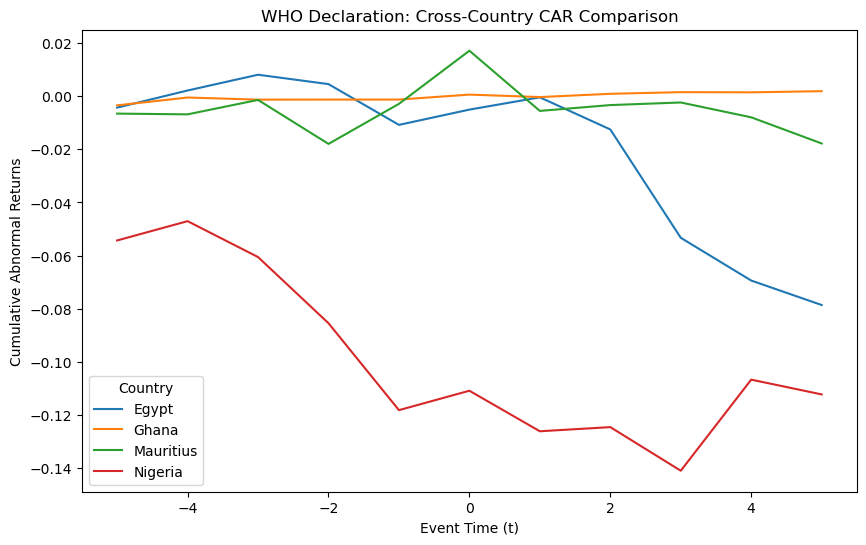

In [74]:
who_comparison_pivot.plot(figsize=(10,6))

plt.title('WHO Declaration: Cross-Country CAR Comparison')
plt.xlabel('Event Time (t)')
plt.ylabel('Cumulative Abnormal Returns')

plt.show()

## **Cross-Country WHO Declaration Results**

The WHO pandemic declaration generated heterogeneous market reactions across African stock exchanges.

- Ghana recorded positive cumulative abnormal returns throughout the event window, indicating investor optimism and market resilience.

- Nigeria experienced the largest negative cumulative abnormal returns, suggesting strong investor panic and high sensitivity to global shocks.

- Egypt showed a sustained decline in cumulative abnormal returns, indicating persistent investor pessimism following the announcement.

- Mauritius recorded mild negative cumulative abnormal returns, suggesting relatively limited market volatility compared to other countries.

Overall, the findings suggest that African stock markets responded differently to the WHO pandemic declaration, with Ghana showing the most resilience and Nigeria experiencing the strongest negative reaction.

## **Cross-Country Comparison: First Cases**

In [75]:
# Country labels
ghana_first_summary['Country'] = 'Ghana'
nigeria_first_summary['Country'] = 'Nigeria'
egypt_first_summary['Country'] = 'Egypt'
mauritius_first_summary['Country'] = 'Mauritius'

In [76]:
# combining results
first_case_comparison = pd.concat([
    ghana_first_summary,
    nigeria_first_summary,
    egypt_first_summary,
    mauritius_first_summary
])

first_case_comparison

,t,N,AAR,CAAR,Avg_Firm_CAR,t_stat_AAR,t_stat_CAAR,p_val_AAR,p_val_CAAR,Sig_AAR,Sig_CAAR,Country
0,-5,39,0.002924,-0.001794,-0.001788,1.853546,-0.056236,0.071580,0.955449,*,,Ghana
1,-4,39,-0.000803,-0.002598,-0.002592,-0.999661,-0.081343,0.323798,0.935596,,,Ghana
2,-3,39,0.000008,-0.002590,-0.002584,0.043664,-0.081082,0.965401,0.935803,,,Ghana
3,-2,39,0.000003,-0.002586,-0.002580,0.017842,-0.080980,0.985858,0.935883,,,Ghana
4,-1,39,0.001872,-0.000714,-0.000708,0.567916,-0.022215,0.573432,0.982393,,,Ghana
5,0,39,-0.000937,-0.001651,-0.001645,-0.560802,-0.051387,0.578225,0.959286,,,Ghana
6,1,39,0.001209,-0.000442,-0.000436,0.999828,-0.013764,0.323718,0.989090,,,Ghana
7,2,39,0.000607,0.000165,0.000172,0.839792,0.005147,0.406278,0.995920,,,Ghana
8,3,39,-0.000069,0.000097,0.000103,-0.023507,0.002961,0.981369,0.997653,,,Ghana
9,4,39,0.000423,0.000520,0.000526,0.459780,0.015893,0.648294,0.987403,,,Ghana


In [77]:
# pivoting
first_case_pivot = first_case_comparison.pivot(
    index='t',
    columns='Country',
    values='CAAR'
)

first_case_pivot

Country,Egypt,Ghana,Mauritius,Nigeria
t,,,,
-5,0.033418,-0.001794,0.002063,0.007014
-4,0.024459,-0.002598,0.021792,-0.001338
-3,0.018776,-0.002590,-0.000260,-0.009506
-2,0.018421,-0.002586,0.002325,-0.008264
-1,0.016038,-0.000714,0.003581,-0.004937
0,0.008064,-0.001651,-0.001848,-0.012345
1,0.006273,-0.000442,-0.010761,-0.024051
2,0.006347,0.000165,-0.013986,-0.045602
3,0.000779,0.000097,NaN,-0.024151


**Cross-Country Comparison: First COVID-19 Case**

This table compares cumulative abnormal returns across Ghana, Nigeria, Egypt, and Mauritius following the first confirmed COVID-19 case in each country.

The comparison highlights differences in domestic market reactions across African stock exchanges.

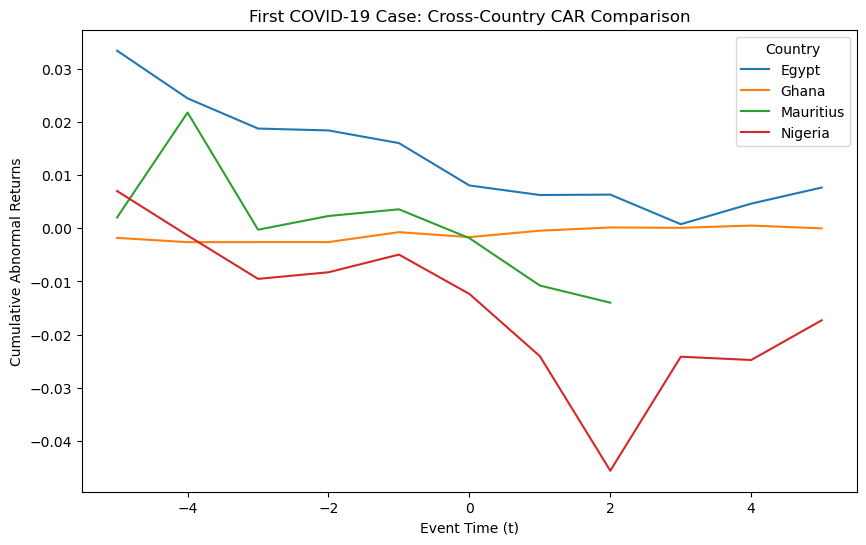

In [78]:
first_case_pivot.plot(figsize=(10,6))

plt.title('First COVID-19 Case: Cross-Country CAR Comparison')
plt.xlabel('Event Time (t)')
plt.ylabel('Cumulative Abnormal Returns')

plt.show()

## **Cross-Country First Case Results**

The first confirmed COVID-19 case generated varying reactions across African stock markets.

- Egypt recorded positive cumulative abnormal returns, indicating investor optimism and confidence following the domestic outbreak.

- Ghana also recorded mild positive cumulative abnormal returns, suggesting limited market panic and relatively stable investor sentiment.

- Nigeria experienced negative cumulative abnormal returns, indicating strong investor concern following the first confirmed case.

- Mauritius recorded negative cumulative abnormal returns, suggesting a decline in market performance following the domestic outbreak.

Overall, the results show heterogeneous domestic market reactions across African stock exchanges.

## **Cross-Country Comparison: Lockdown**

In [79]:
# Country labels
ghana_lockdown_summary['Country'] = 'Ghana'
nigeria_lockdown_summary['Country'] = 'Nigeria'
egypt_lockdown_summary['Country'] = 'Egypt'

In [80]:
# combining results
lockdown_comparison = pd.concat([
    ghana_lockdown_summary,
    nigeria_lockdown_summary,
    egypt_lockdown_summary
])

lockdown_comparison

,t,N,AAR,CAAR,Avg_Firm_CAR,t_stat_AAR,t_stat_CAAR,p_val_AAR,p_val_CAAR,Sig_AAR,Sig_CAAR,Country
0,-5,40,0.000084,0.013257,0.012899,0.398917,0.381279,0.692130,0.705066,,,Ghana
1,-4,40,-0.000152,0.013105,0.012747,-0.392345,0.375691,0.696939,0.709183,,,Ghana
2,-3,40,-0.000291,0.012814,0.012455,-0.625134,0.366253,0.535524,0.716156,,,Ghana
3,-2,40,-0.001727,0.011087,0.010728,-0.916478,0.316089,0.365049,0.753620,,,Ghana
4,-1,40,0.000062,0.011149,0.010791,0.285303,0.317303,0.776922,0.752706,,,Ghana
5,0,40,-0.000017,0.011132,0.010773,-0.055522,0.316324,0.956006,0.753444,,,Ghana
6,1,40,0.002015,0.013147,0.012789,0.941503,0.376003,0.352243,0.708953,,,Ghana
7,2,40,-0.000017,0.013130,0.012772,-0.078174,0.375048,0.938089,0.709657,,,Ghana
8,3,40,-0.002868,0.010263,0.009904,-0.666080,0.324151,0.509281,0.747556,,,Ghana
9,4,40,-0.002328,0.007934,0.007576,-1.337949,0.249318,0.188663,0.804423,,,Ghana


In [81]:
# pivot table
lockdown_pivot = lockdown_comparison.pivot(
    index='t',
    columns='Country',
    values='CAAR'
)

lockdown_pivot

Country,Egypt,Ghana,Nigeria
t,,,
-5,-0.020850,0.013257,-0.093764
-4,-0.031909,0.013105,-0.083338
-3,-0.013468,0.012814,-0.065021
-2,0.021491,0.011087,-0.062735
-1,0.042554,0.011149,-0.055496
0,0.059367,0.011132,-0.054746
1,0.068870,0.013147,-0.059481
2,0.082343,0.013130,-0.056915
3,0.081329,0.010263,-0.068430


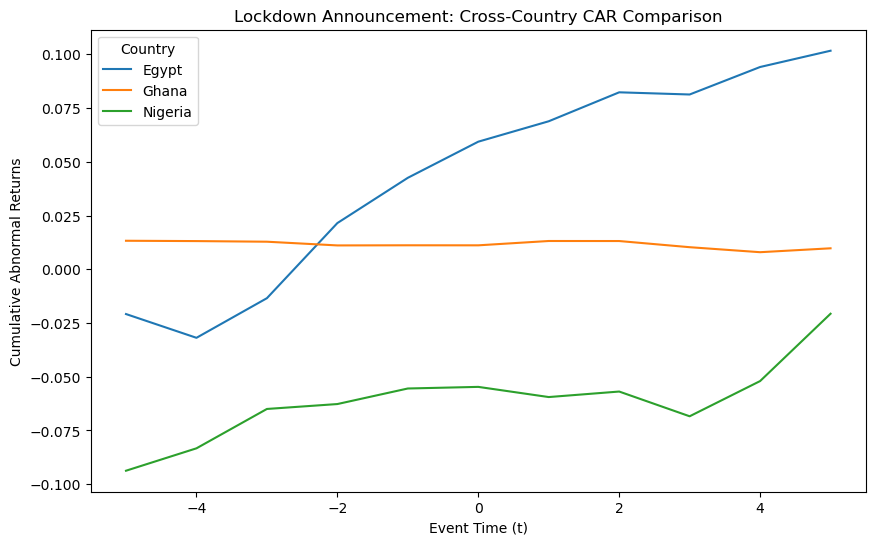

In [82]:
lockdown_pivot.plot(figsize=(10,6))

plt.title('Lockdown Announcement: Cross-Country CAR Comparison')
plt.xlabel('Event Time (t)')
plt.ylabel('Cumulative Abnormal Returns')

plt.show()

# **Final Multi-Country Event Study Results**

This study examined firm-level stock market reactions across four African stock exchanges — Ghana, Nigeria, Egypt, and Mauritius — during major COVID-19 events.

The analysis applied a firm-level market model using a 120-day estimation window and an event window of [-5, +5].

---

## WHO Pandemic Declaration

The WHO declaration generated heterogeneous reactions across markets:

- Ghana recorded positive cumulative abnormal returns, indicating market resilience.
- Nigeria experienced strong negative cumulative abnormal returns, suggesting investor panic.
- Egypt recorded sustained negative abnormal returns following the announcement.
- Mauritius recorded mild negative reactions, indicating limited market volatility.

These results suggest that African markets responded differently to global pandemic announcements.

---

## First COVID-19 Case

Domestic outbreak announcements also generated varying reactions:

- Egypt recorded positive cumulative abnormal returns, suggesting investor optimism.
- Ghana recorded mild positive abnormal returns, indicating limited market disruption.
- Nigeria recorded negative cumulative abnormal returns, indicating strong investor concern.
- Mauritius recorded negative cumulative abnormal returns, reflecting market uncertainty.

These results indicate that domestic outbreak announcements influenced investor sentiment differently across markets.

---

## Lockdown

Lockdown announcements generated more positive market reactions:

- Egypt recorded the strongest positive cumulative abnormal returns.
- Ghana recorded mild positive cumulative abnormal returns.
- Nigeria experienced initial negative reactions followed by recovery.
- Mauritius was excluded due to limited trading data.

These findings suggest that containment measures improved investor confidence.

---

## Overall Findings

Across all events:

- Ghana demonstrated consistent market resilience
- Nigeria exhibited the highest market sensitivity
- Egypt recorded strong positive reactions during lockdown
- Mauritius recorded moderate and mixed responses

Overall, the results indicate heterogeneous responses across African stock markets during the COVID-19 pandemic, with policy announcements influencing investor behaviour differently across countries.

In [87]:
!pip install xlsxwriter

In [88]:
output_excel = "../data/processed/Multi_Country_Event_Study_updated_01.xlsx"

with pd.ExcelWriter(output_excel, engine="xlsxwriter") as writer:
    
    # WHO Results
    ghana_who_output.to_excel(writer, sheet_name="Ghana_WHO", index=False)
    nigeria_who_output.to_excel(writer, sheet_name="Nigeria_WHO", index=False)
    egypt_who_output.to_excel(writer, sheet_name="Egypt_WHO", index=False)
    mauritius_who_output.to_excel(writer, sheet_name="Mauritius_WHO", index=False)
    

    # First Case Results
    ghana_first_output.to_excel(writer, sheet_name="Ghana_FirstCase", index=False)
    nigeria_first_output.to_excel(writer, sheet_name="Nigeria_FirstCase", index=False)
    egypt_first_output.to_excel(writer, sheet_name="Egypt_FirstCase", index=False)
    mauritius_first_output.to_excel(writer, sheet_name="Mauritius_FirstCase", index=False)
    

    # Lockdown Results
    ghana_lockdown_output.to_excel(writer, sheet_name="Ghana_Lockdown", index=False)
    nigeria_lockdown_output.to_excel(writer, sheet_name="Nigeria_Lockdown", index=False)
    egypt_lockdown_output.to_excel(writer, sheet_name="Egypt_Lockdown", index=False)
    

    # Cross-Country Comparisons
    who_comparison_pivot.to_excel(writer, sheet_name="WHO_Comparison")
    first_case_pivot.to_excel(writer, sheet_name="FirstCase_Comparison")
    lockdown_pivot.to_excel(writer, sheet_name="Lockdown_Comparison")
    

    # Firm-level datasets
    ghana_who_data.to_excel(writer, sheet_name="Ghana_WHO_Firm", index=False)
    nigeria_who_data.to_excel(writer, sheet_name="Nigeria_WHO_Firm", index=False)
    egypt_who_data.to_excel(writer, sheet_name="Egypt_WHO_Firm", index=False)
    mauritius_who_data.to_excel(writer, sheet_name="Mauritius_WHO_Firm", index=False)
    
    ghana_first_data.to_excel(writer, sheet_name="Ghana_First_Firm", index=False)
    nigeria_first_data.to_excel(writer, sheet_name="Nigeria_First_Firm", index=False)
    egypt_first_data.to_excel(writer, sheet_name="Egypt_First_Firm", index=False)
    mauritius_first_data.to_excel(writer, sheet_name="Mauritius_First_Firm", index=False)
    
    ghana_lockdown_data.to_excel(writer, sheet_name="Ghana_Lockdown_Firm", index=False)
    nigeria_lockdown_data.to_excel(writer, sheet_name="Nigeria_Lockdown_Firm", index=False)
    egypt_lockdown_data.to_excel(writer, sheet_name="Egypt_Lockdown_Firm", index=False)
    

    # Graph Data for Excel Charts
    who_comparison_pivot.to_excel(writer, sheet_name="WHO_Graph_Data")
    first_case_pivot.to_excel(writer, sheet_name="FirstCase_Graph_Data")
    lockdown_pivot.to_excel(writer, sheet_name="Lockdown_Graph_Data")
    
    # Workbook / chart formatting
    workbook = writer.book

    title_format = workbook.add_format({
        "bold": True,
        "font_size": 14
    })

    # ---------- WHO CHART ----------
    who_ws = writer.sheets["WHO_Comparison"]
    who_ws.write("H1", "WHO Declaration: Cross-Country CAR Comparison", title_format)

    who_chart = workbook.add_chart({"type": "line"})

    for i, col in enumerate(who_comparison_pivot.columns):
        who_chart.add_series({
            "name":       ["WHO_Comparison", 0, i + 1],
            "categories": ["WHO_Comparison", 1, 0, len(who_comparison_pivot), 0],
            "values":     ["WHO_Comparison", 1, i + 1, len(who_comparison_pivot), i + 1],
            "line":       {"width": 2.25},
        })

    who_chart.set_title({"name": "WHO Declaration: Cross-Country CAR Comparison"})
    who_chart.set_x_axis({"name": "Event Time (t)"})
    who_chart.set_y_axis({"name": "Cumulative Abnormal Returns"})
    who_chart.set_legend({"position": "bottom"})
    who_chart.set_size({"width": 720, "height": 420})
    who_chart.set_plotarea({"border": {"none": True}})
    who_chart.set_chartarea({"border": {"none": True}})

    who_ws.insert_chart("H3", who_chart)

    # ---------- FIRST CASE CHART ----------
    first_ws = writer.sheets["FirstCase_Comparison"]
    first_ws.write("H1", "First COVID-19 Case: Cross-Country CAR Comparison", title_format)

    first_chart = workbook.add_chart({"type": "line"})

    for i, col in enumerate(first_case_pivot.columns):
        first_chart.add_series({
            "name":       ["FirstCase_Comparison", 0, i + 1],
            "categories": ["FirstCase_Comparison", 1, 0, len(first_case_pivot), 0],
            "values":     ["FirstCase_Comparison", 1, i + 1, len(first_case_pivot), i + 1],
            "line":       {"width": 2.25},
        })

    first_chart.set_title({"name": "First COVID-19 Case: Cross-Country CAR Comparison"})
    first_chart.set_x_axis({"name": "Event Time (t)"})
    first_chart.set_y_axis({"name": "Cumulative Abnormal Returns"})
    first_chart.set_legend({"position": "bottom"})
    first_chart.set_size({"width": 720, "height": 420})
    first_chart.set_plotarea({"border": {"none": True}})
    first_chart.set_chartarea({"border": {"none": True}})

    first_ws.insert_chart("H3", first_chart)

    # ---------- LOCKDOWN CHART ----------
    lock_ws = writer.sheets["Lockdown_Comparison"]
    lock_ws.write("H1", "Lockdown Announcement: Cross-Country CAR Comparison", title_format)

    lock_chart = workbook.add_chart({"type": "line"})

    for i, col in enumerate(lockdown_pivot.columns):
        lock_chart.add_series({
            "name":       ["Lockdown_Comparison", 0, i + 1],
            "categories": ["Lockdown_Comparison", 1, 0, len(lockdown_pivot), 0],
            "values":     ["Lockdown_Comparison", 1, i + 1, len(lockdown_pivot), i + 1],
            "line":       {"width": 2.25},
        })

    lock_chart.set_title({"name": "Lockdown Announcement: Cross-Country CAR Comparison"})
    lock_chart.set_x_axis({"name": "Event Time (t)"})
    lock_chart.set_y_axis({"name": "Cumulative Abnormal Returns"})
    lock_chart.set_legend({"position": "bottom"})
    lock_chart.set_size({"width": 720, "height": 420})
    lock_chart.set_plotarea({"border": {"none": True}})
    lock_chart.set_chartarea({"border": {"none": True}})

    lock_ws.insert_chart("H3", lock_chart)

print(f"Excel with charts created successfully: {output_excel}")

Excel with charts created successfully: ../data/processed/Multi_Country_Event_Study_updated_01.xlsx
